In [1]:
library(dplyr)
library(ggplot2)
library(data.table)

source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/top_corr_module_fxns.R")

theme_set(default_theme())
options(repr.matrix.max.cols=Inf) 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: future


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


The following objects are masked from ‘package:data.table’:

    dcast, melt




In [2]:
setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp")

Goal: verify enriched modules actually represent a given cell type by plotting cell type abundance vs. the module eigengene

In [3]:
# These should match the settings used to get enrichment results in previous step

mod_def <- "PosBC"
strict <- FALSE
lfc_threshold <- 3
pval_threshold <- 0.05

In [4]:
ctype_genes_list <- readRDS("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/data/DE_genes/yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_dream.RDS")
ctypes <- unique(sapply(strsplit(names(ctype_genes_list), "_vs_"), "[", 1))
n_signif_wrt <- length(ctypes)-2
if (strict) {
    n_signif_wrt <- NULL
}

ctype_genes_list <- prep_pairwise_DE_genes(ctype_genes_list, pval_threshold=pval_threshold, lfc_threshold=lfc_threshold, strict=strict, n_signif_wrt=n_signif_wrt)
ctype_genes_list <- ctype_genes_list[lengths(ctype_genes_list) > 2]
names(ctype_genes_list) <- unlist(sapply(names(ctype_genes_list), function(x) gsub(" ", "_", x)))

### 20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules

In [13]:
network_dir <- "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_20pcntCells_25SD_200samples_legend_08-11-55.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments.csv")

In [14]:
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub(" ", "_", x))
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub("/", "_", x, fixed=TRUE))

In [15]:
top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
cornsilk2,Sst,24.78,0.7594550,0.01671062,8.405550e-17,1.133229e-146,"Lurap1l, Calb1, Rbp4, Elfn1, Fstl5, Vgf, Kctd8, Tnni3k, Cfap20dc, Moxd1, Arnt2, Fibcd1, Wnt16, Gm14418, Myh8","Chodl, Nos1, Crhbp, Sit1, P2rx2, Rln1, Tacr1, Krt18, Bace2, Insl6, Ache, Col25a1, Cdh1, Npy, Krt27","1700086L19Rik-1, 2610318N02Rik, 4930426D05Rik, 8030443G20Rik, 9330158H04Rik, 9430021M05Rik, 9630002D21Rik, A230077H06Rik, A2ml1, A530058N18Rik-1, A930003A15Rik, Abtb3, Ache, Acrbp, Ada",cornsilk2,black,Bicor-None_signum0.257_minSize6_merge_ME_0.97_20250,Bicor-None_signum0.971_minSize3_merge_ME_0.97_20250,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.257_minSize6_merge_ME_0.97_20250/Module_eigengenes_11-01-40.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.971_minSize3_merge_ME_0.97_20250/Module_eigengenes_08-38-01.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.257_minSize6_merge_ME_0.97_20250/kME_table_11-01-40.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.971_minSize3_merge_ME_0.97_20250/kME_table_08-38-01.csv
lightgoldenrod41,L6_IT_CTX,24.54,0.6149473,0.61494730,1.465997e-03,1.140344e-03,"C1ql3, Gm37811, Pter, Enc1, Adamts13, Liat1, Dok5, Mas1, Bdnf, Bhlha9, Lrrtm4, Robo3, Slc26a4, Gm6569, Gm32793","C1ql3, Gm37811, Pter, Enc1, Adamts13, Liat1, Bhlha9, Lrrtm4, Robo3, Slc26a4, Gm6569, Gm32793, Dmkn, Ntrk3, NA","Fst, Slc26a4, Vegfd, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA",lightgoldenrod4,dodgerblue3,Bicor-None_signum0.257_minSize6_merge_ME_0.97_20250,Bicor-None_signum0.291_minSize4_merge_ME_0.97_20250,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.257_minSize6_merge_ME_0.97_20250/Module_eigengenes_11-01-40.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.291_minSize4_merge_ME_0.97_20250/Module_eigengenes_10-09-18.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.257_minSize6_merge_ME_0.97_20250/kME_table_11-01-40.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_mergeParam0.97_subsetCutoff851.92_Modules/Bicor-None_signum0.291_minSize4_merge_ME_0.97_20250/kME_table_10-09-18.csv
lightgoldenrod4,L6_CT_CTX,24.88,0.6841889,0.64618972,9.331078e-12,2.155657e-21,"Hs3st2, Gm36736, Trbc2, Arhgap25, Efhd2, Garnl3, Krt80, Sptbn5, Ramp3, Fancd2, Abracl, Gm10635, Prss3l, NA, NA","Rprm, Ppp1r1b, Ighm, Prss35, Foxp2, Arhgap25, Ramp3, Trbc2, Krt80, Sebox, Stim2, Gm10635, H60b, Pgam2, Lsp1","Foxp2, Gm10635, Gm30564, Gm35853, Gm40518, Gm41673, H60b, Ighm, Krt80, Obs

In [ ]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)

### 10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules

In [6]:
network_dir <- "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_10pcntCells_5SD_200samples_legend_02-36-30.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments.csv")

In [7]:
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub(" ", "_", x))
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub("/", "_", x, fixed=TRUE))

In [8]:
top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
slateblue3,Sst,5.16,0.4094423,-0.01372584,6.772267e-14,1.084343e-61,"Nrsn2, Gm14164, Calb1, Moxd1, Rgs17, Gria1, Rab3b, Rcan2, Klf5, Elfn1, Laptm4b, Rab27b, Rbp4, NA, NA","Chodl, Nos1, Crhbp, Sit1, P2rx2, Bace2, Tacr1, Rln1, Npy, Ache, Slc7a3, Insl6, Krt27, Col25a1, Krt18","1700086L19Rik-1, 2610318N02Rik, 4930426D05Rik, 8030443G20Rik, 9330158H04Rik, 9430021M05Rik, 9630002D21Rik, A230077H06Rik, A2ml1, A530058N18Rik-1, A930003A15Rik, Abtb3, Ache, Acrbp, Ada",slateblue3,floralwhite,Bicor-None_signum0.135_minSize6_merge_ME_0.95_18409,Bicor-None_signum0.742_minSize3_merge_ME_0.95_18409,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.135_minSize6_merge_ME_0.95_18409/Module_eigengenes_01-12-46.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.742_minSize3_merge_ME_0.95_18409/Module_eigengenes_11-10-10.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.135_minSize6_merge_ME_0.95_18409/kME_table_01-12-46.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.742_minSize3_merge_ME_0.95_18409/kME_table_11-10-10.csv
honeydew4,L5_PT_CTX,4.79,0.3190624,0.02558351,1.000000e+00,1.000000e+00,"Erc2, Dgkh, ENSMUSG00000121908, Unc13a, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA","Rpl23, Atp6v1f, Higd2a, Gm9794, Mrps33, Pomp, Ndufs8, Rabac1, Trappc2l, Clta, Lamtor4, Mrps12, BC031181, Ier3ip1, Pigyl","9930014A18Rik, Cldn23, Gm11730, Gm19410, Lratd2, Npr3, NA, NA, NA, NA, NA, NA, NA, NA, NA",honeydew4,antiquewhite4,Bicor-None_signum0.209_minSize4_merge_ME_0.95_18409,Bicor-None_signum0.135_minSize10_merge_ME_0.95_18409,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.209_minSize4_merge_ME_0.95_18409/Module_eigengenes_11-39-18.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.135_minSize10_merge_ME_0.95_18409/Module_eigengenes_01-30-49.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.209_minSize4_merge_ME_0.95_18409/kME_table_11-39-18.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_5SD_200samples_mergeParam0.95_subsetCutoff763.45_Modules/Bicor-None_signum0.135_minSize10_merge_ME_0.95_18409/kME_table_01-30-49.csv
goldenrod1,L6_IT_CTX,4.87,0.3465234,0.30885230,3.259010e-04,3.259010e-04,"C1ql3, Gm37811, Pter, Vegfd, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA","C1ql3, Gm37811, Pter, Vegfd, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA","Fst, Slc26a4, Vegfd, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA",goldenrod1,chocolate1,Bicor-None_signum0.209_minSize4_merge_ME_0.95_18409,Bicor-None_signum0.135_m

In [ ]:
# plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)

### 10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules

In [5]:
network_dir <- "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_10pcntCells_20SD_200samples_legend_02-37-49.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments.csv")

In [6]:
top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
bisque,Sst,21.31,0.8014266,-0.05984665,1.251446e-18,3.747688e-145,"Calb1, Rbp4, Kctd8, Sptb, Cfap20dc, Rab27b, Col19a1, Mkx, Stxbp6, Gm31218, Fibcd1, Cdh7, Minar1, 9630002D21Rik, Hunk","Chodl, Crhbp, Nos1, Sit1, Rln1, P2rx2, Bace2, Insl6, Krt18, Col25a1, Npy, Tacr1, Ndst4, Ache, Krt27","1700086L19Rik-1, 2610318N02Rik, 4930426D05Rik, 8030443G20Rik, 9330158H04Rik, 9430021M05Rik, 9630002D21Rik, A230077H06Rik, A2ml1, A530058N18Rik-1, A930003A15Rik, Abtb3, Ache, Acrbp, Ada",bisque,grey60,Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409,Bicor-None_signum0.724_minSize10_merge_ME_0.95_18409,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409/Module_eigengenes_04-27-35.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.724_minSize10_merge_ME_0.95_18409/Module_eigengenes_04-26-20.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409/kME_table_04-27-35.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.724_minSize10_merge_ME_0.95_18409/kME_table_04-26-20.csv
mediumorchid2,L6_IT_CTX,19.72,0.6487180,0.58644290,1.000000e+00,8.146197e-04,"Slc7a4, Ak5, Pfkl, Igsf21, Necab3, Gpr52, Sulf1, Slc26a10, Fancd2os, Prss22, Bmp3, Cwh43, Syt12, Kazald1, AI115009","C1ql3, Gm37811, Pter, Mas1, Rtn4rl2, Adgrd1, Adamts13, Slc26a4, Gm48695, Gm37824, NA, NA, NA, NA, NA","Fst, Slc26a4, Vegfd, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA",mediumorchid2,orchid1,Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409,Bicor-None_signum0.3_minSize4_merge_ME_0.95_18409,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409/Module_eigengenes_04-27-35.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.3_minSize4_merge_ME_0.95_18409/Module_eigengenes_05-34-11.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409/kME_table_04-27-35.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.3_minSize4_merge_ME_0.95_18409/kME_table_05-34-11.csv
slateblue1,L4_5_IT_CTX,19.45,0.7563602,0.68272554,7.492343e-11,2.235783e-13,"Krt12, A830036E02Rik, Dkkl1, Gpr158, Gfra2, Crhr1, Acsl5, Sphkap, Ptgfrn, Sac3d1, Prdm8, Ocm, C030013G03Rik, Nuak1, Gtdc1","Nrxn1, Tmem145, Rims3, Gm10493, Cbln4, Osbp2, Rspo1, Gpr158, Krt12, Cdh12, Fstl4, Hkdc1, Crhr1, Prdm8, Acsl5","2600014E21Rik, BC006965, C030013G03Rik, Cyp39a1, Endou, Gm29674, Mmel1, Plb1,

In [12]:
options(repr.plot.res = 250) 

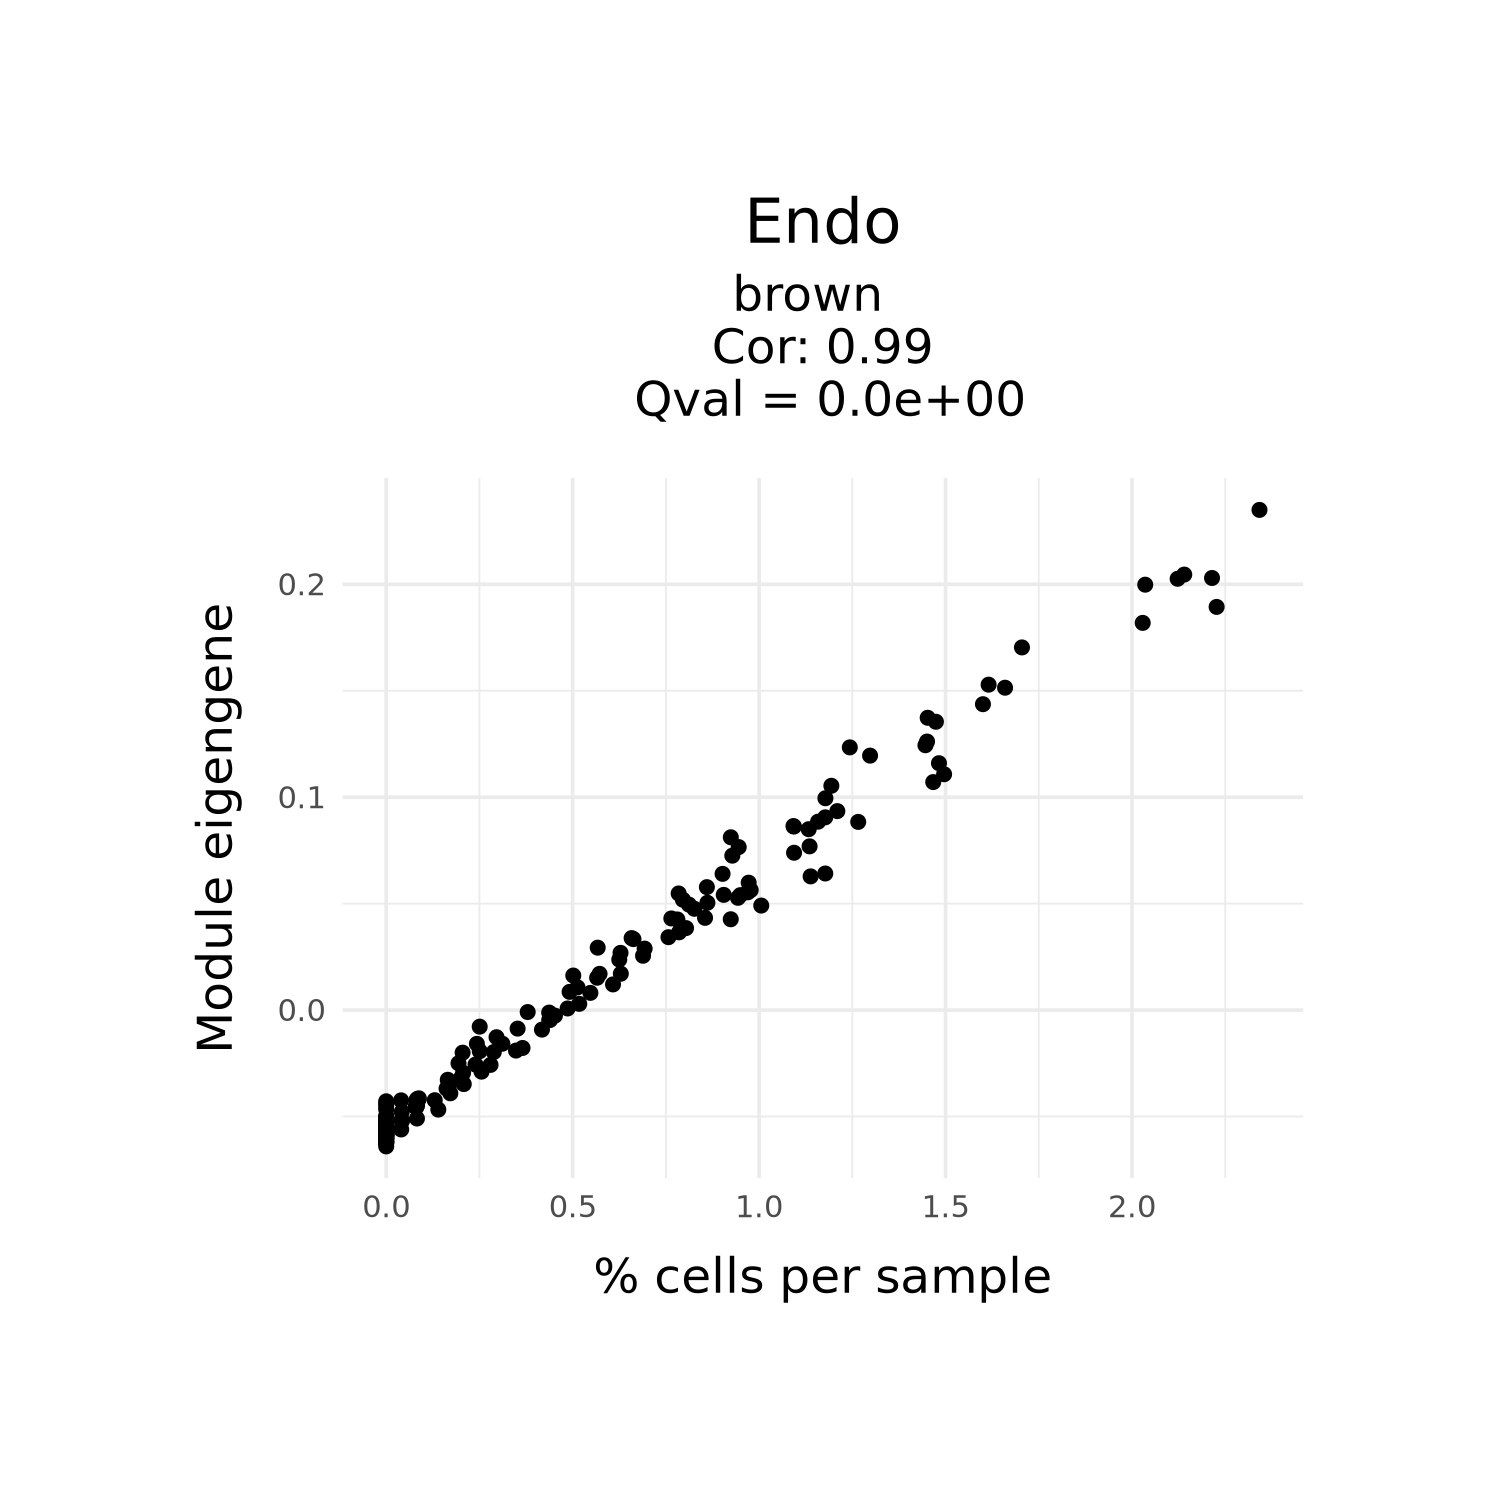

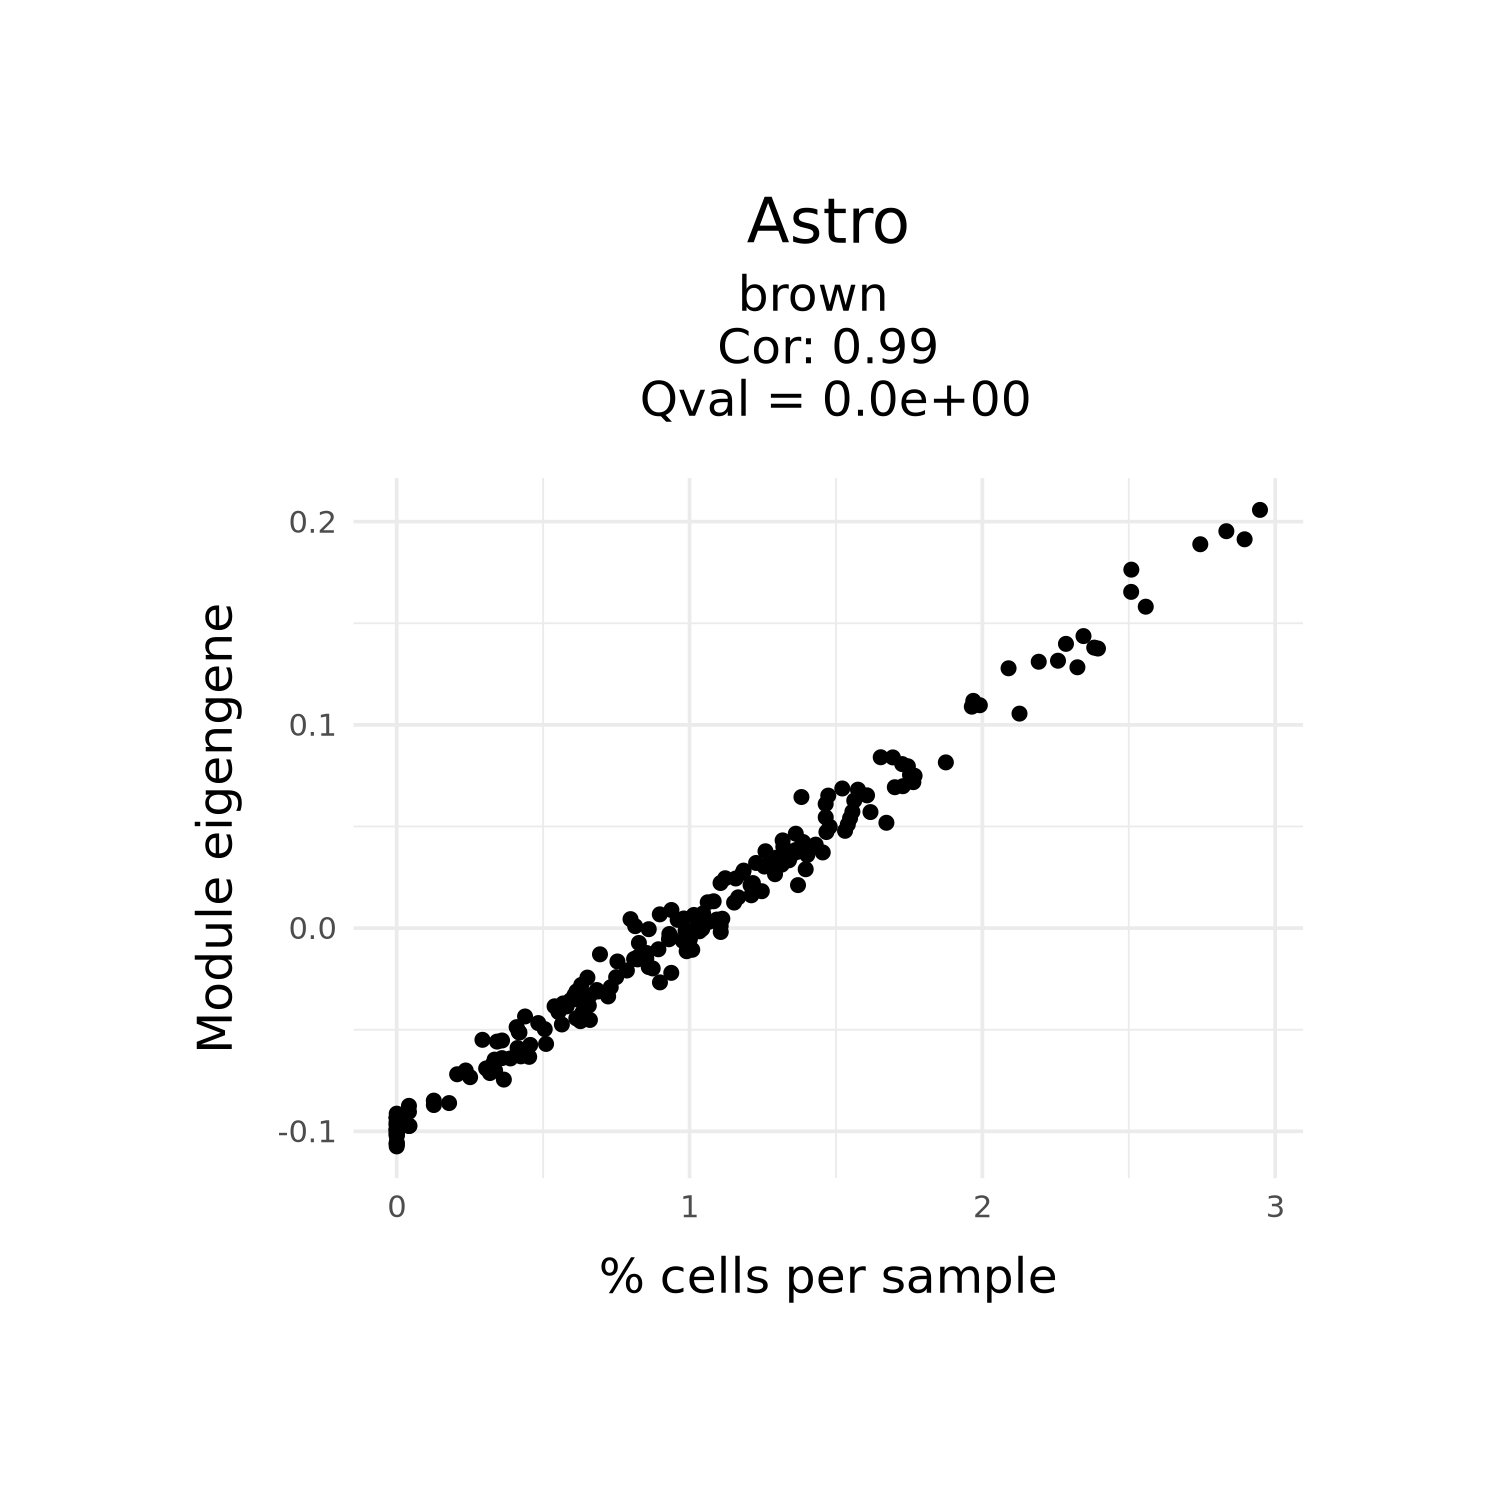

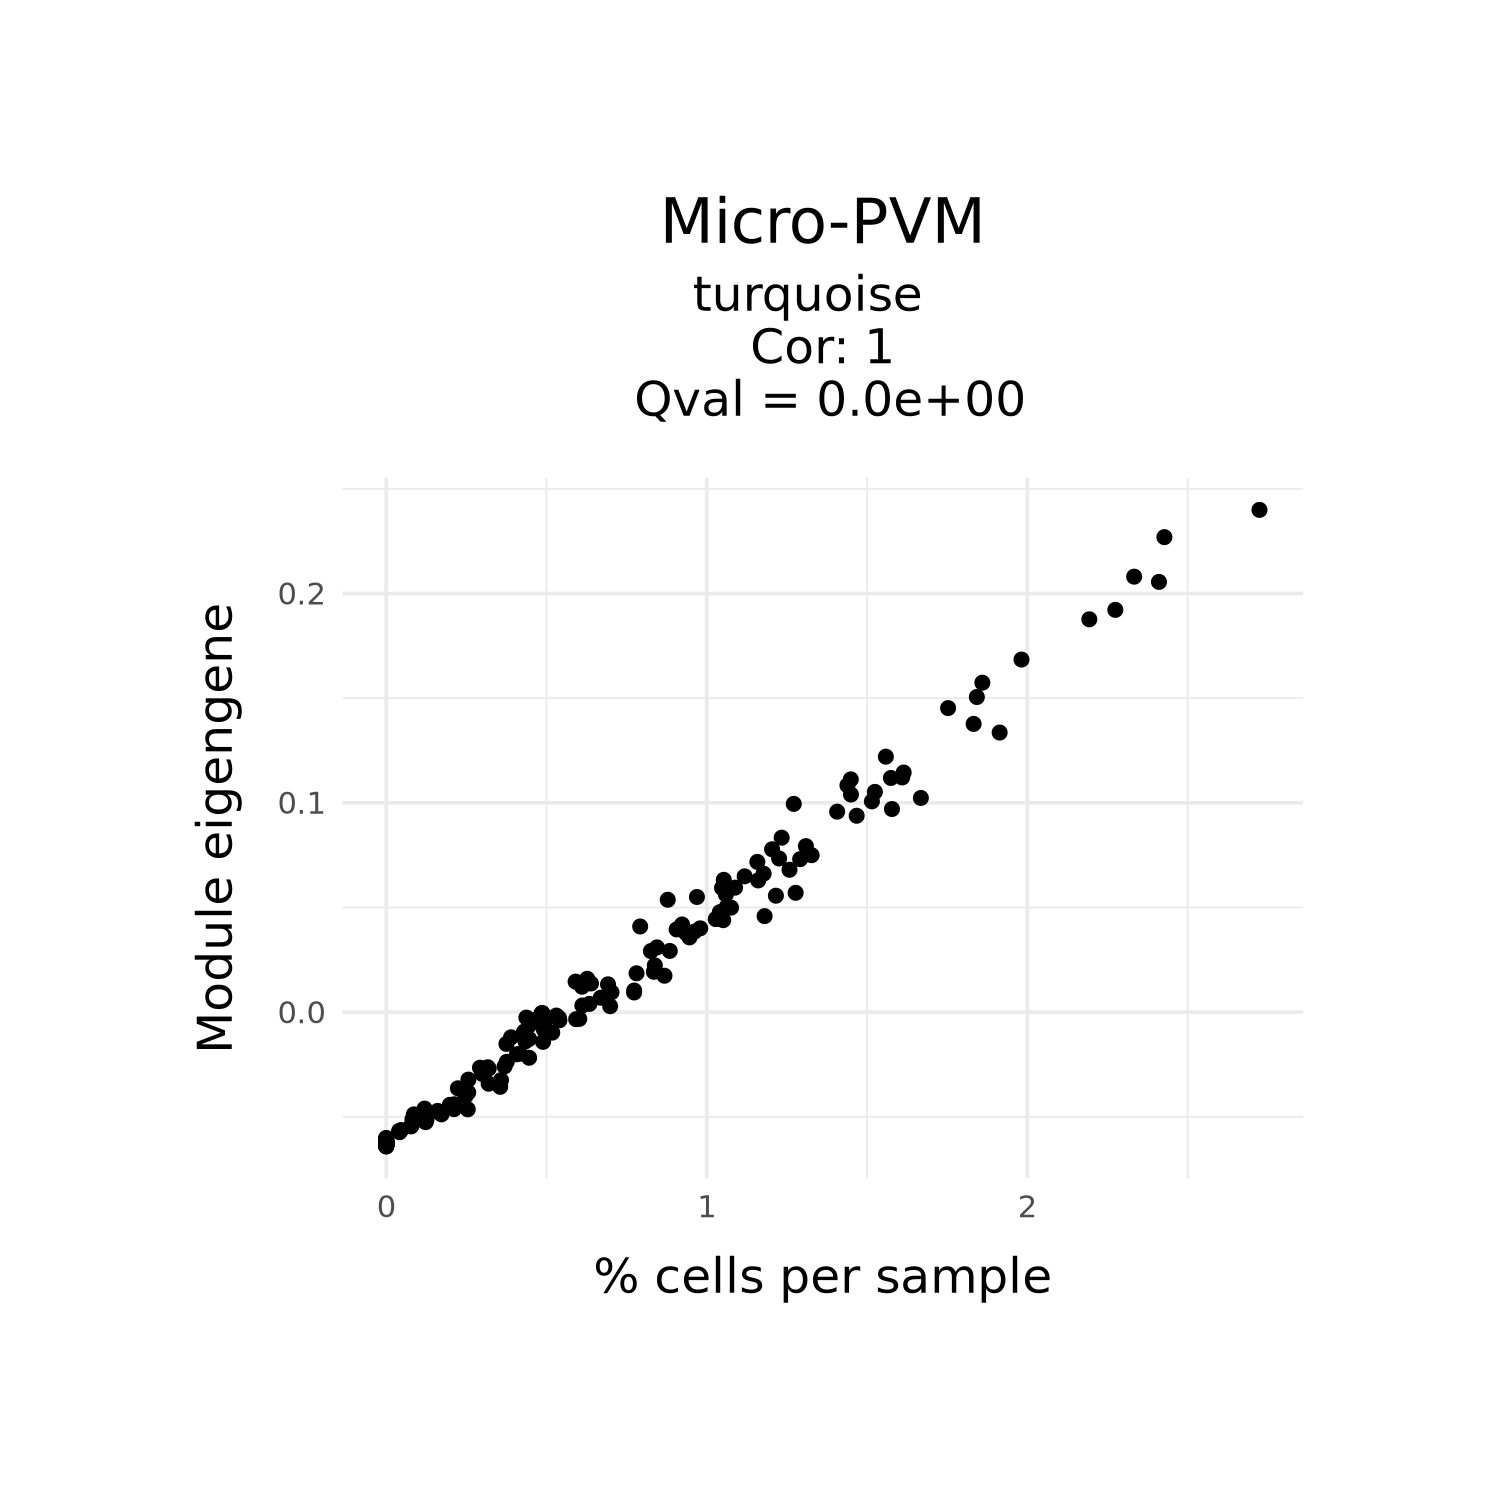

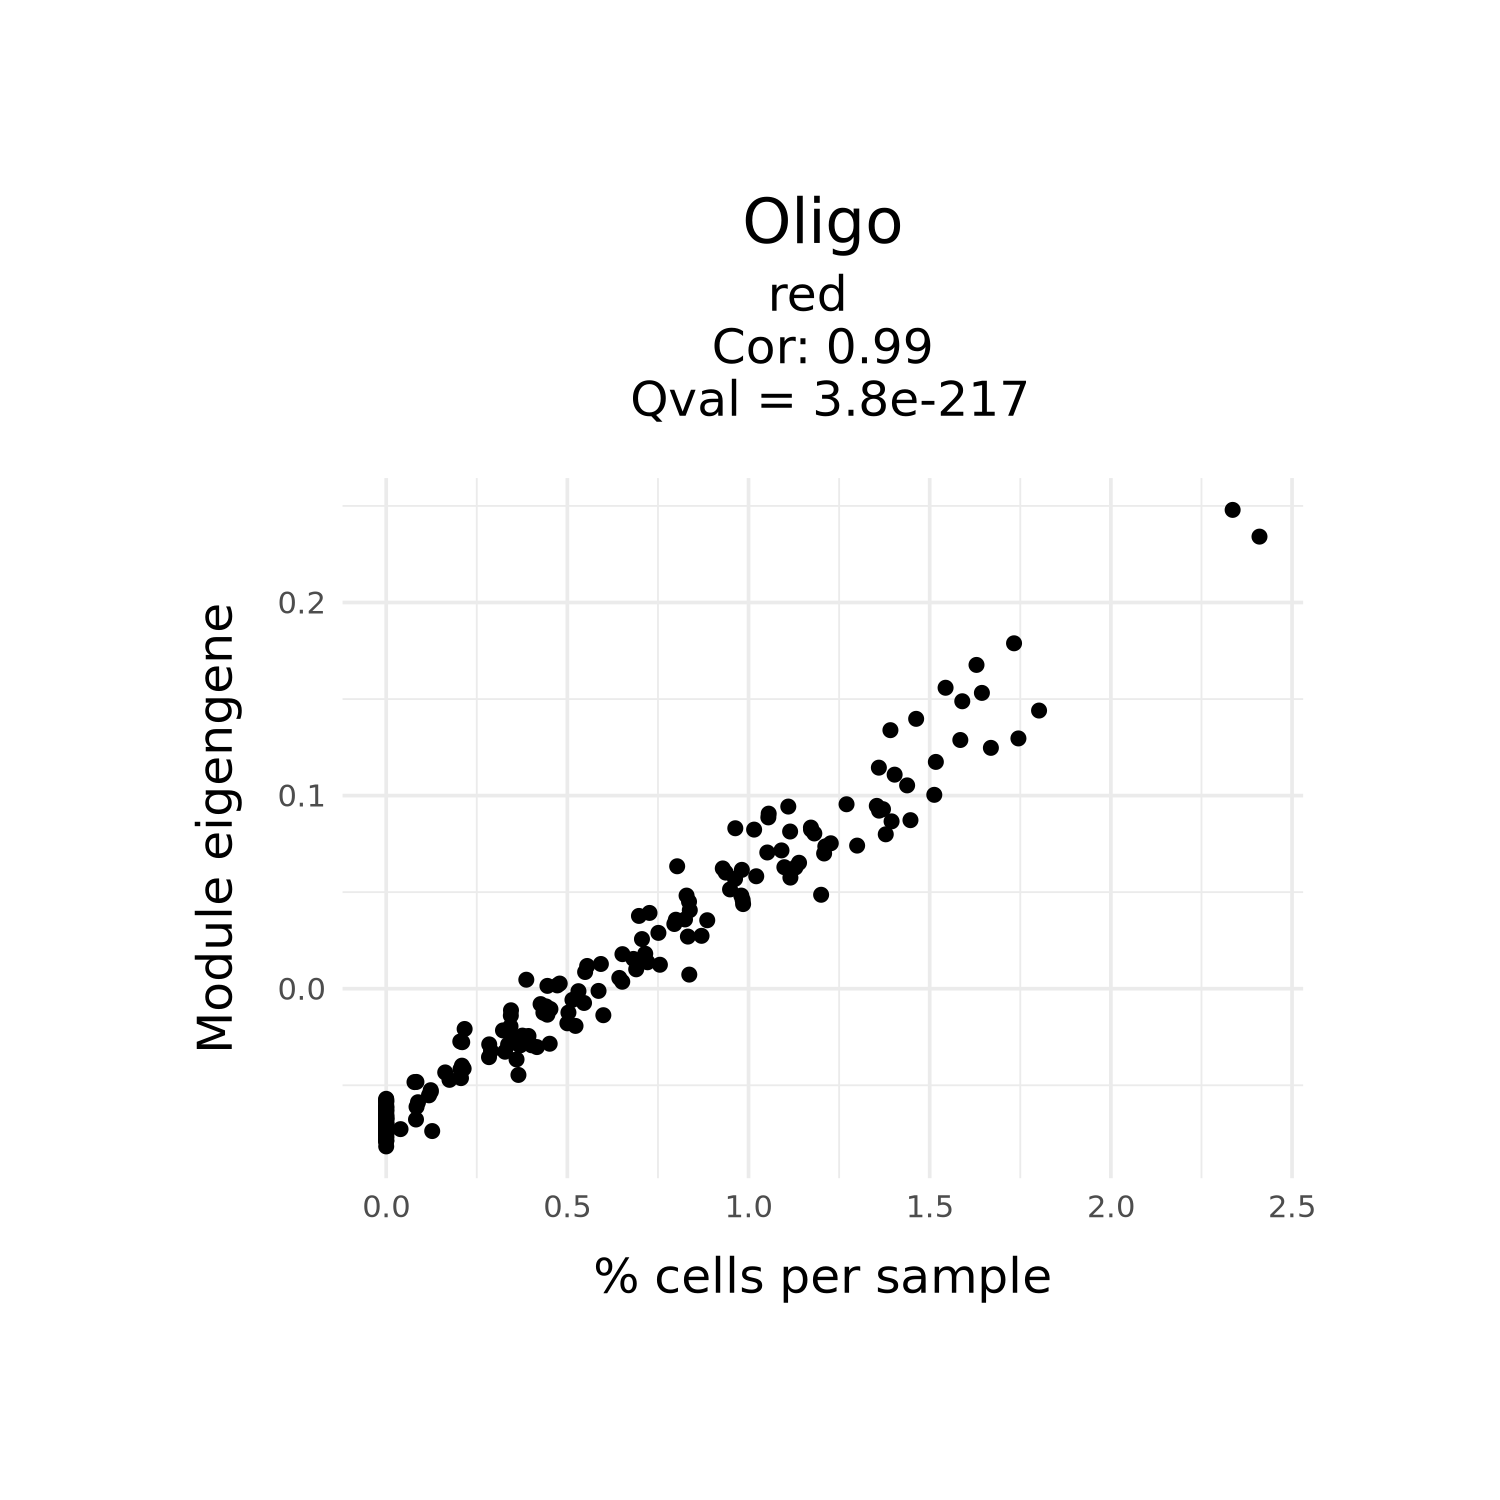

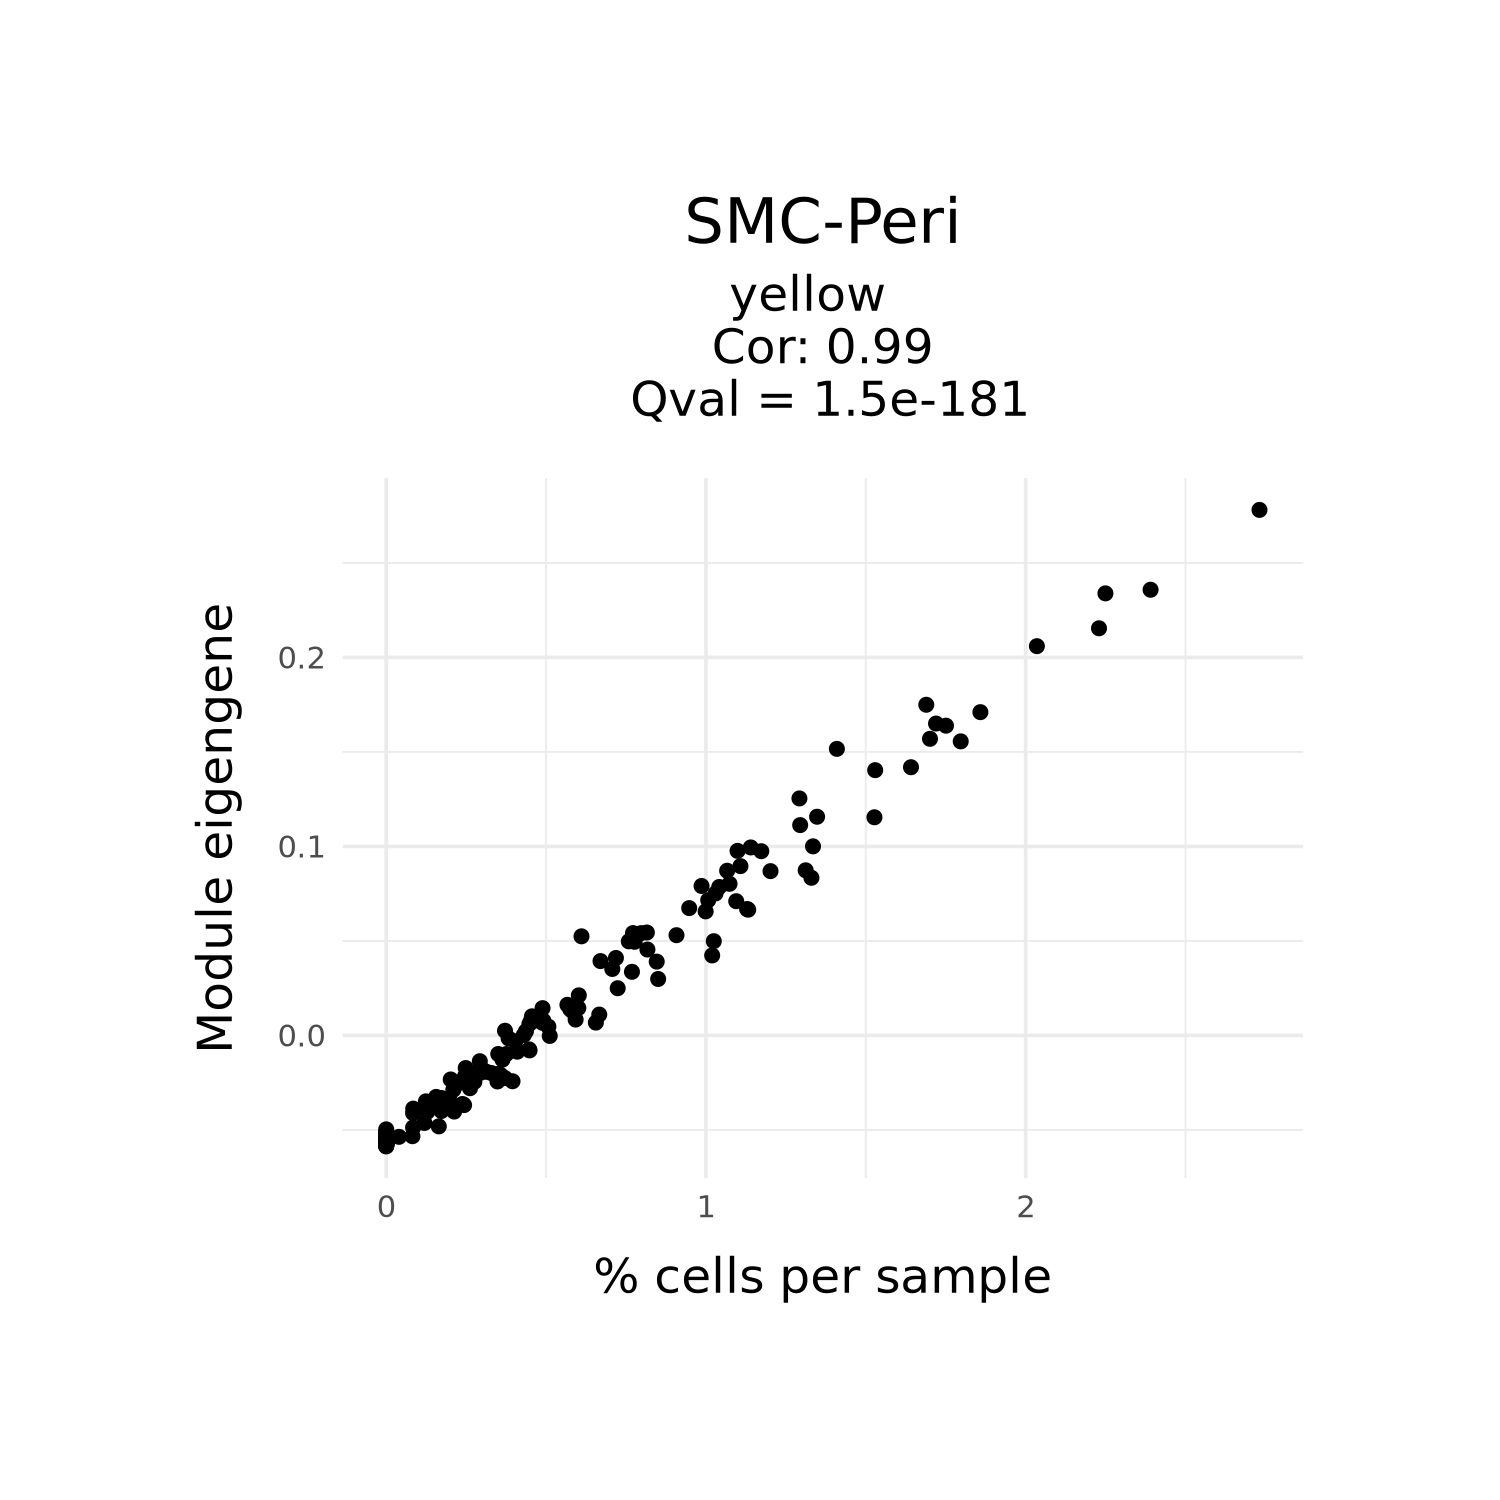

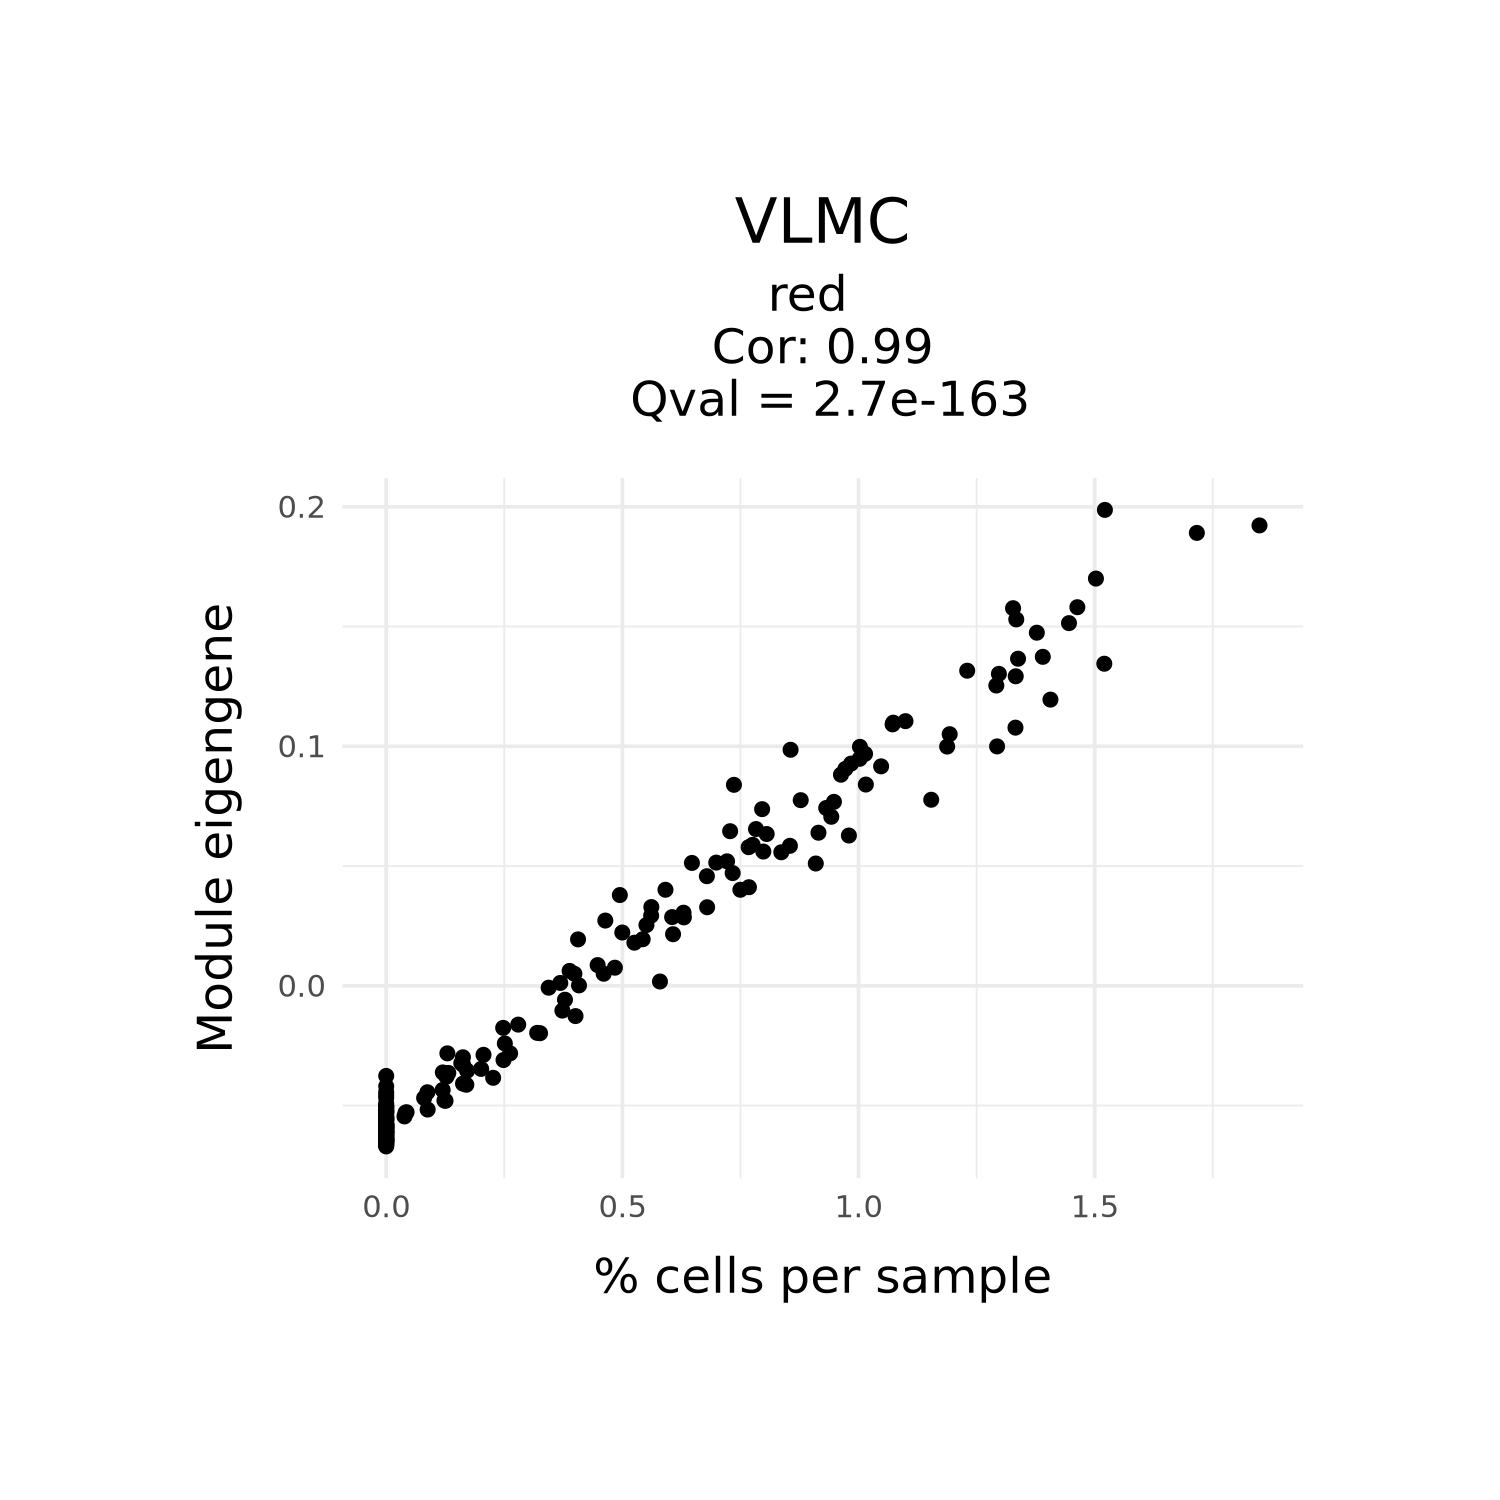

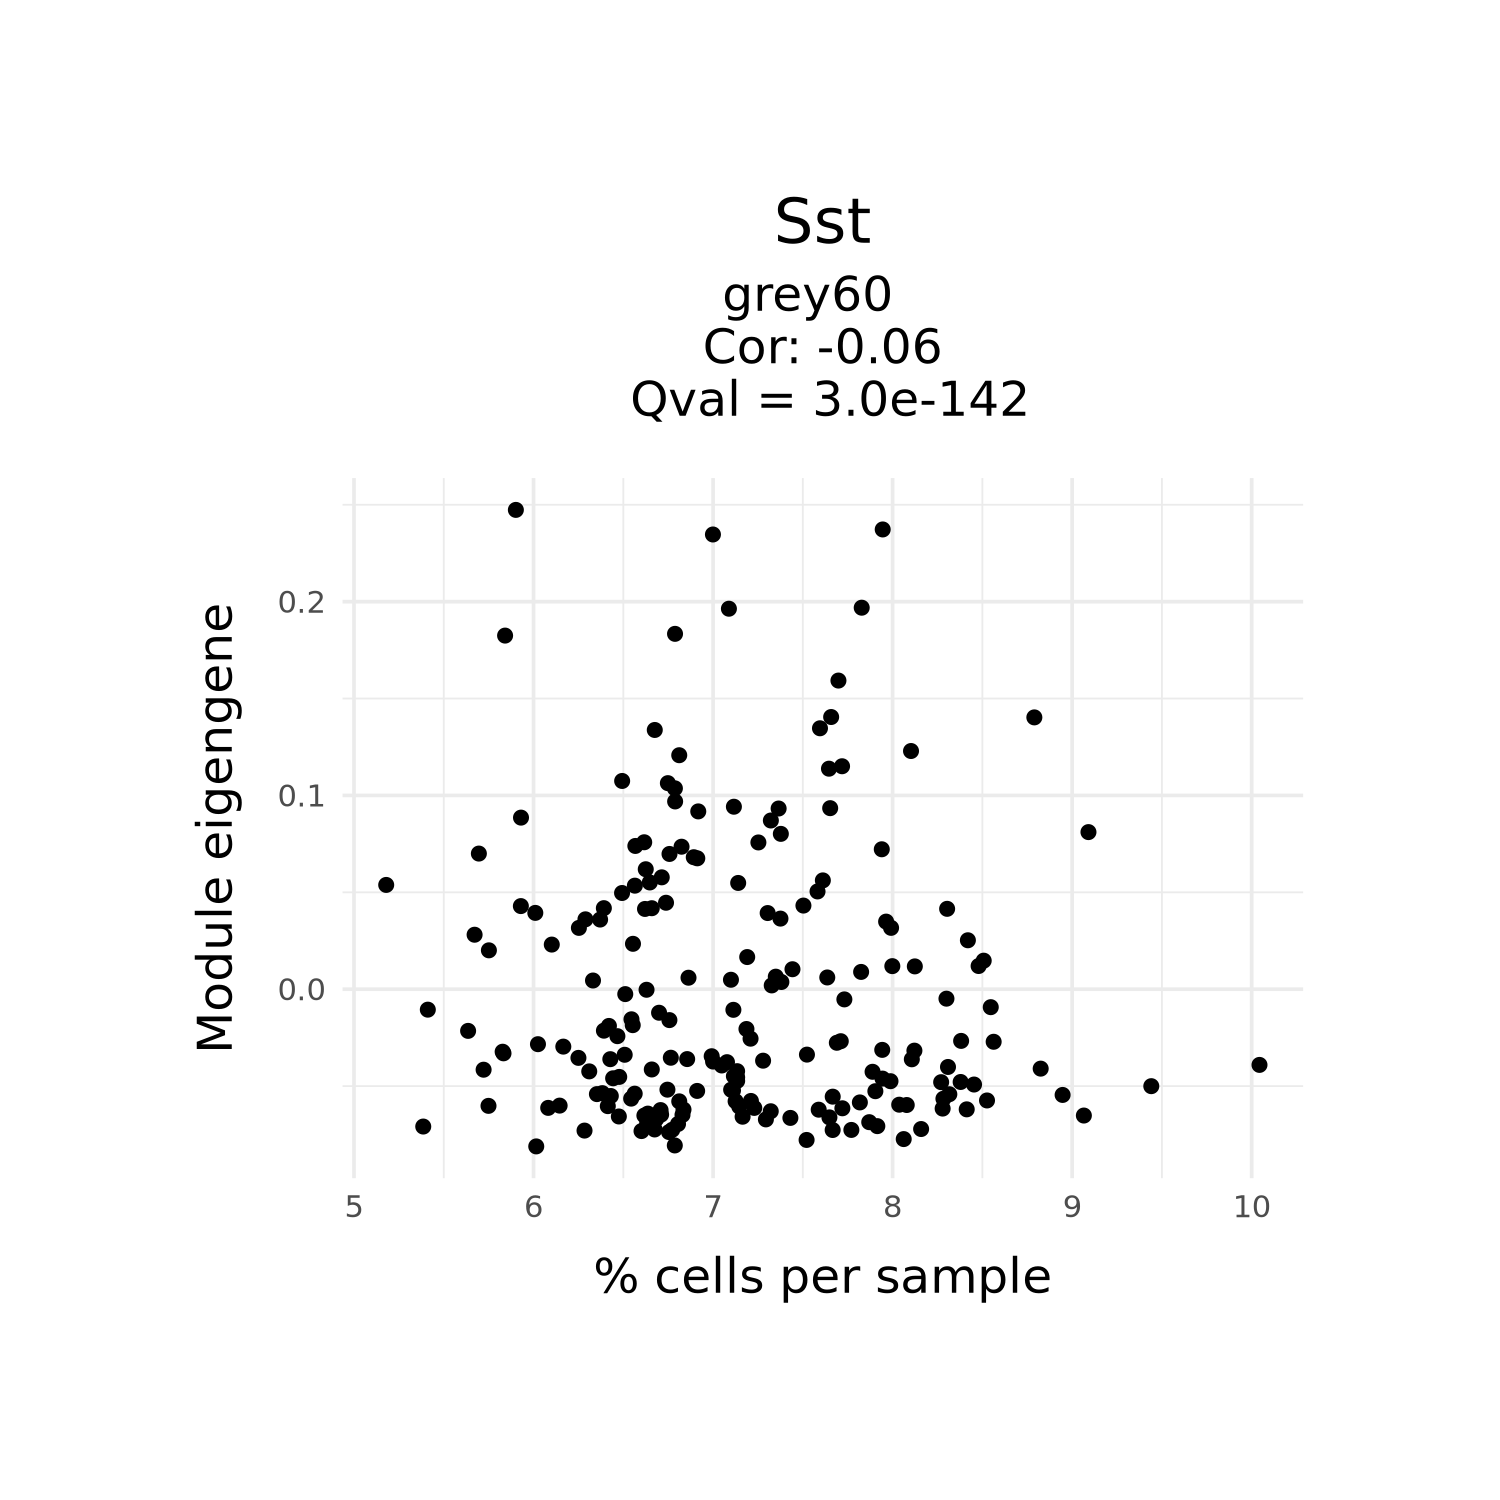

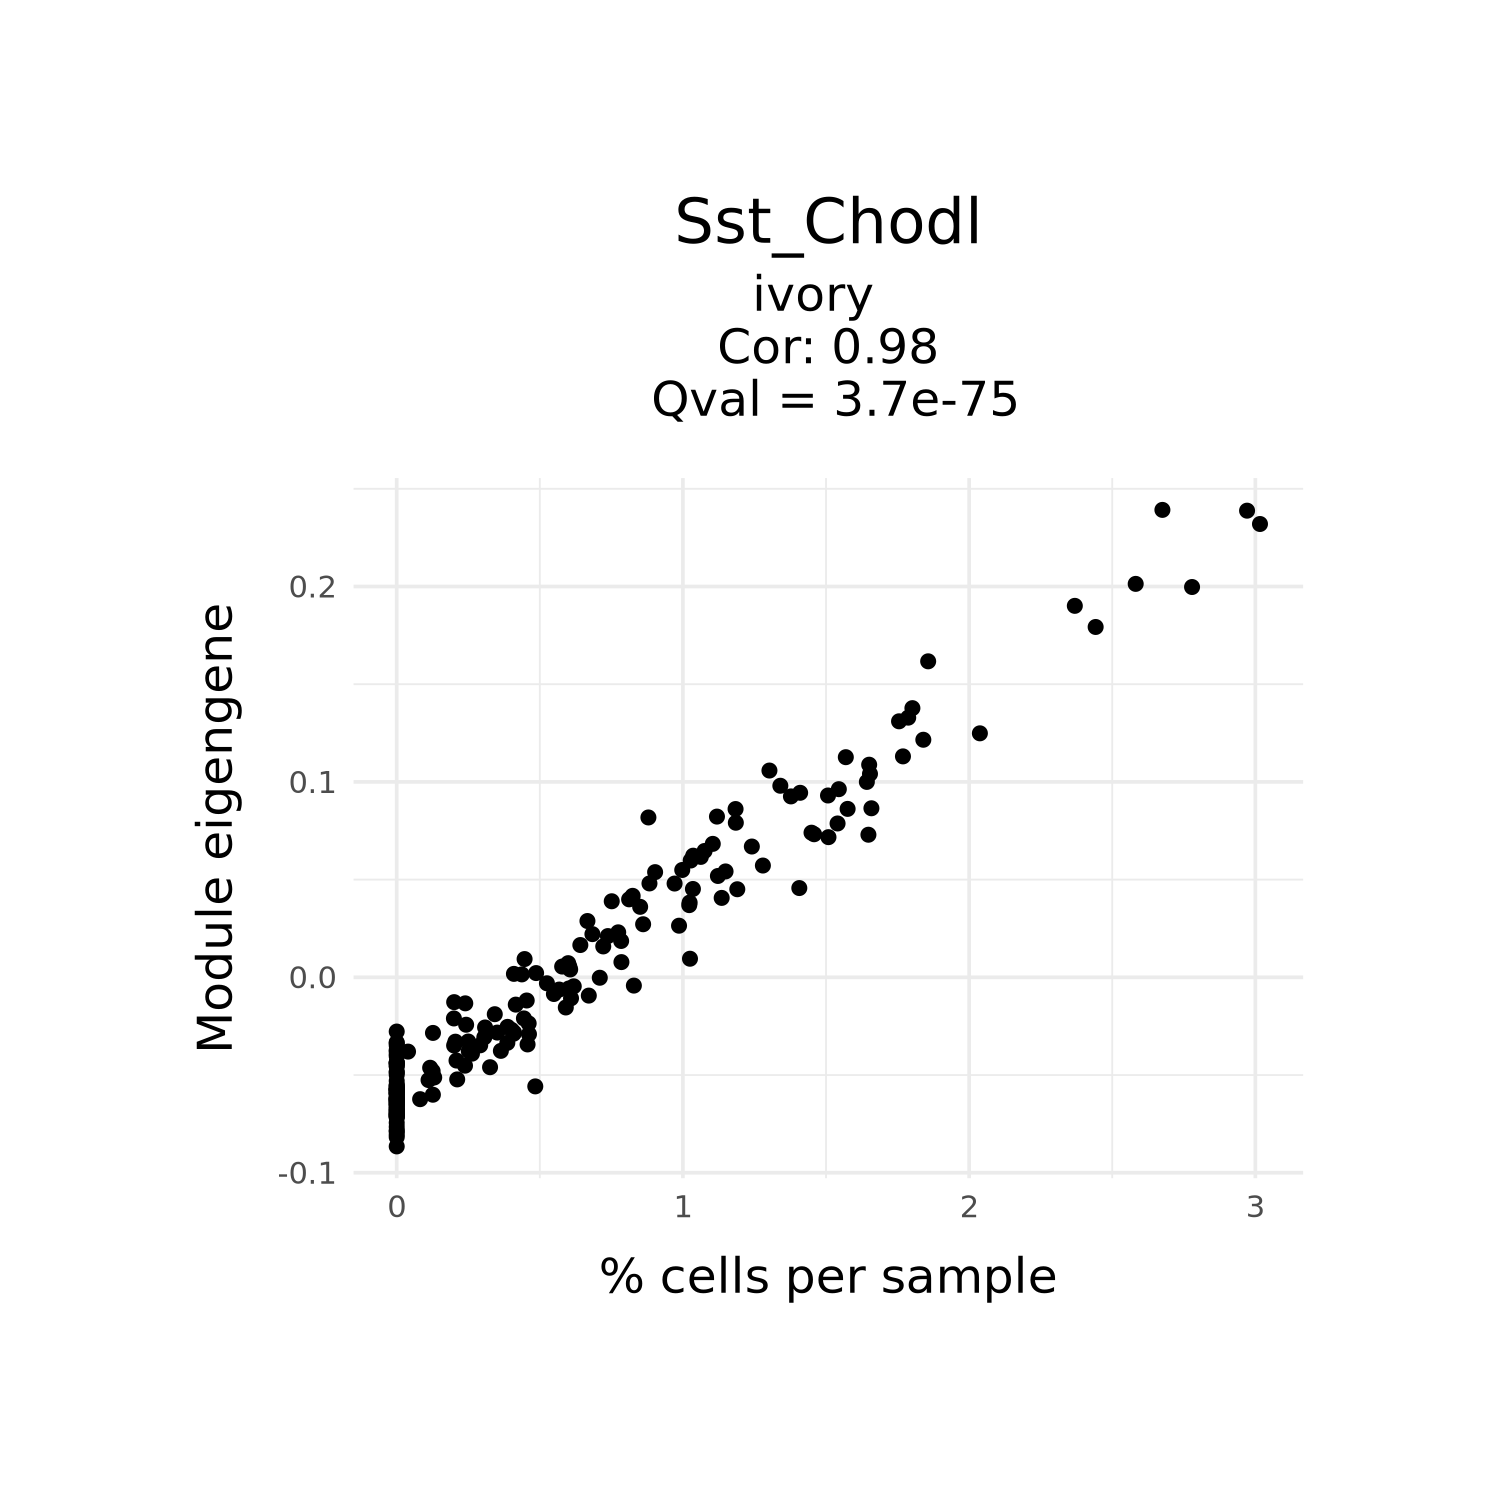

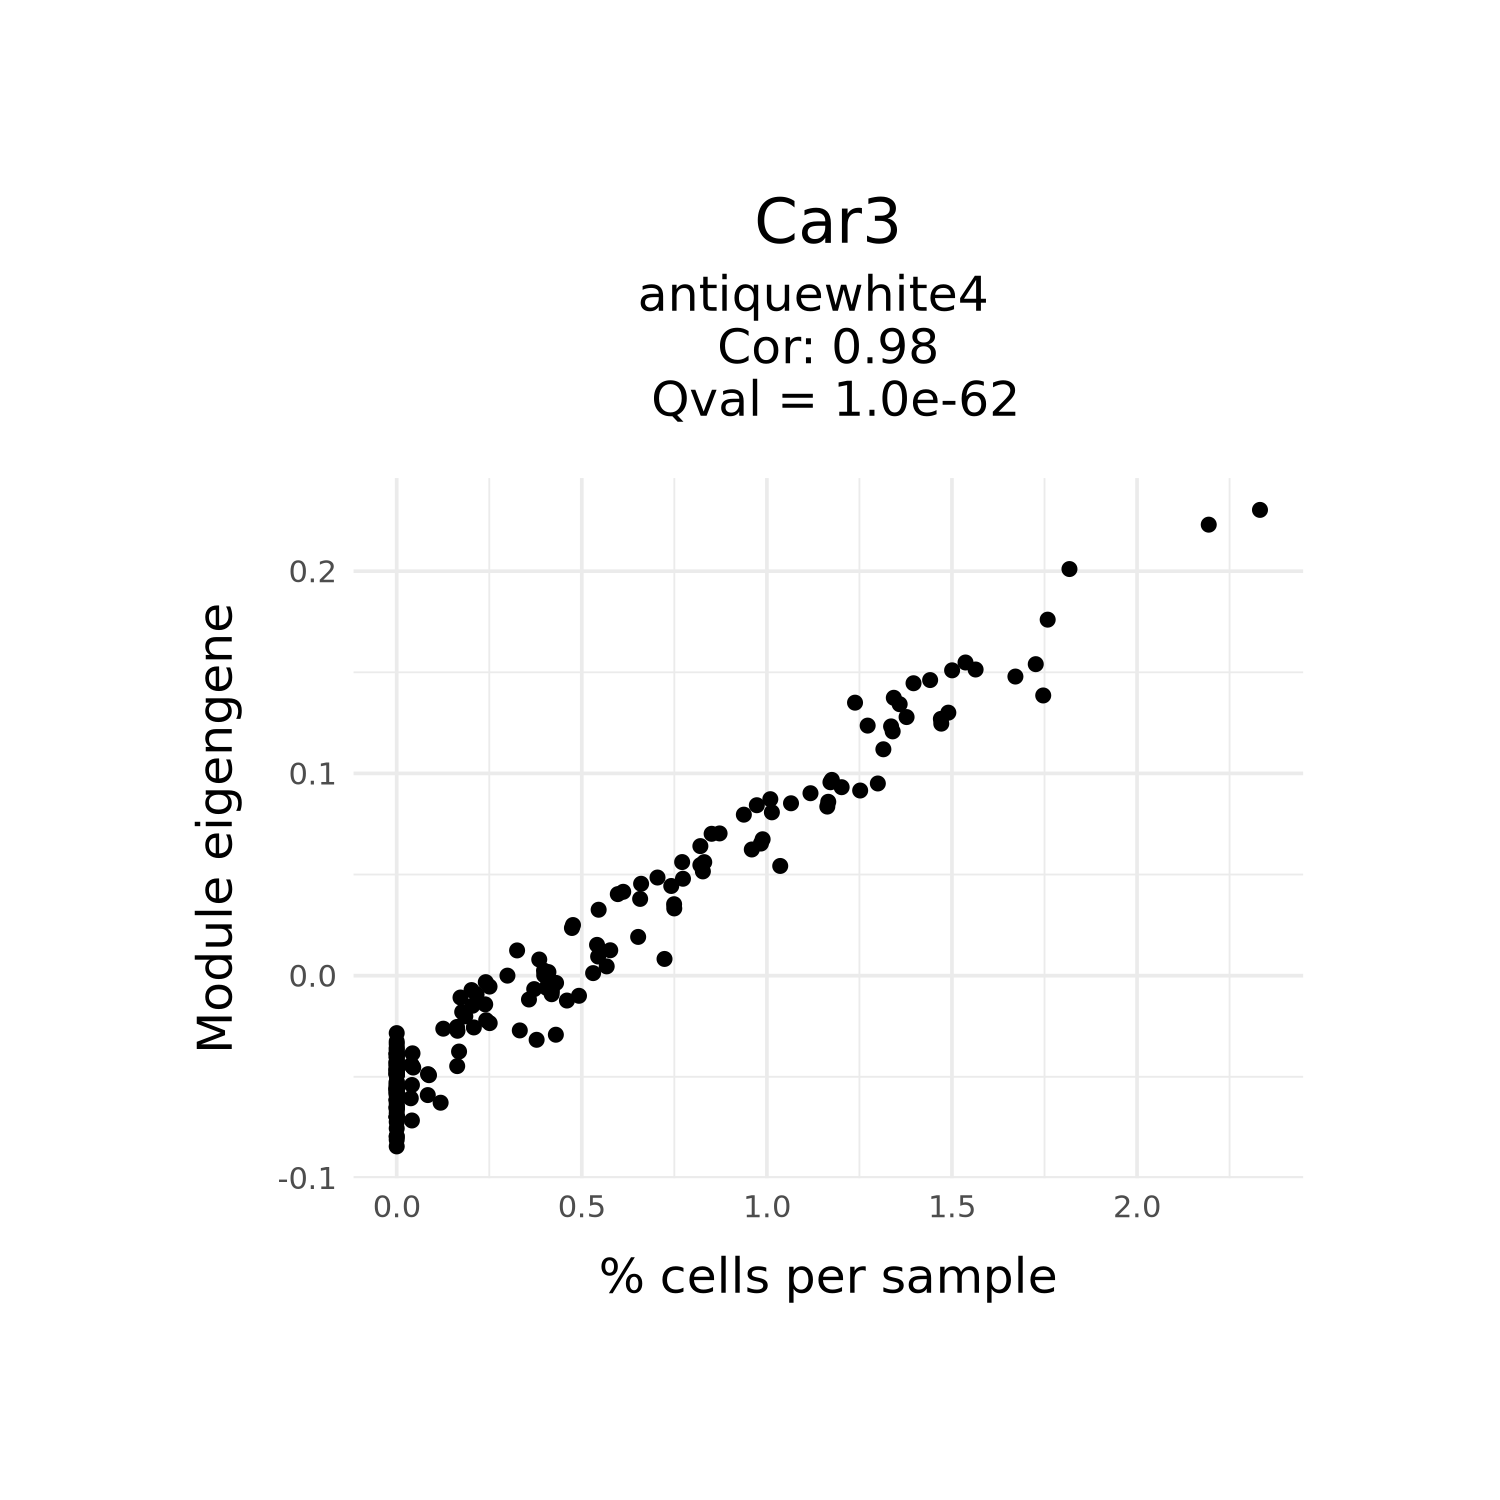

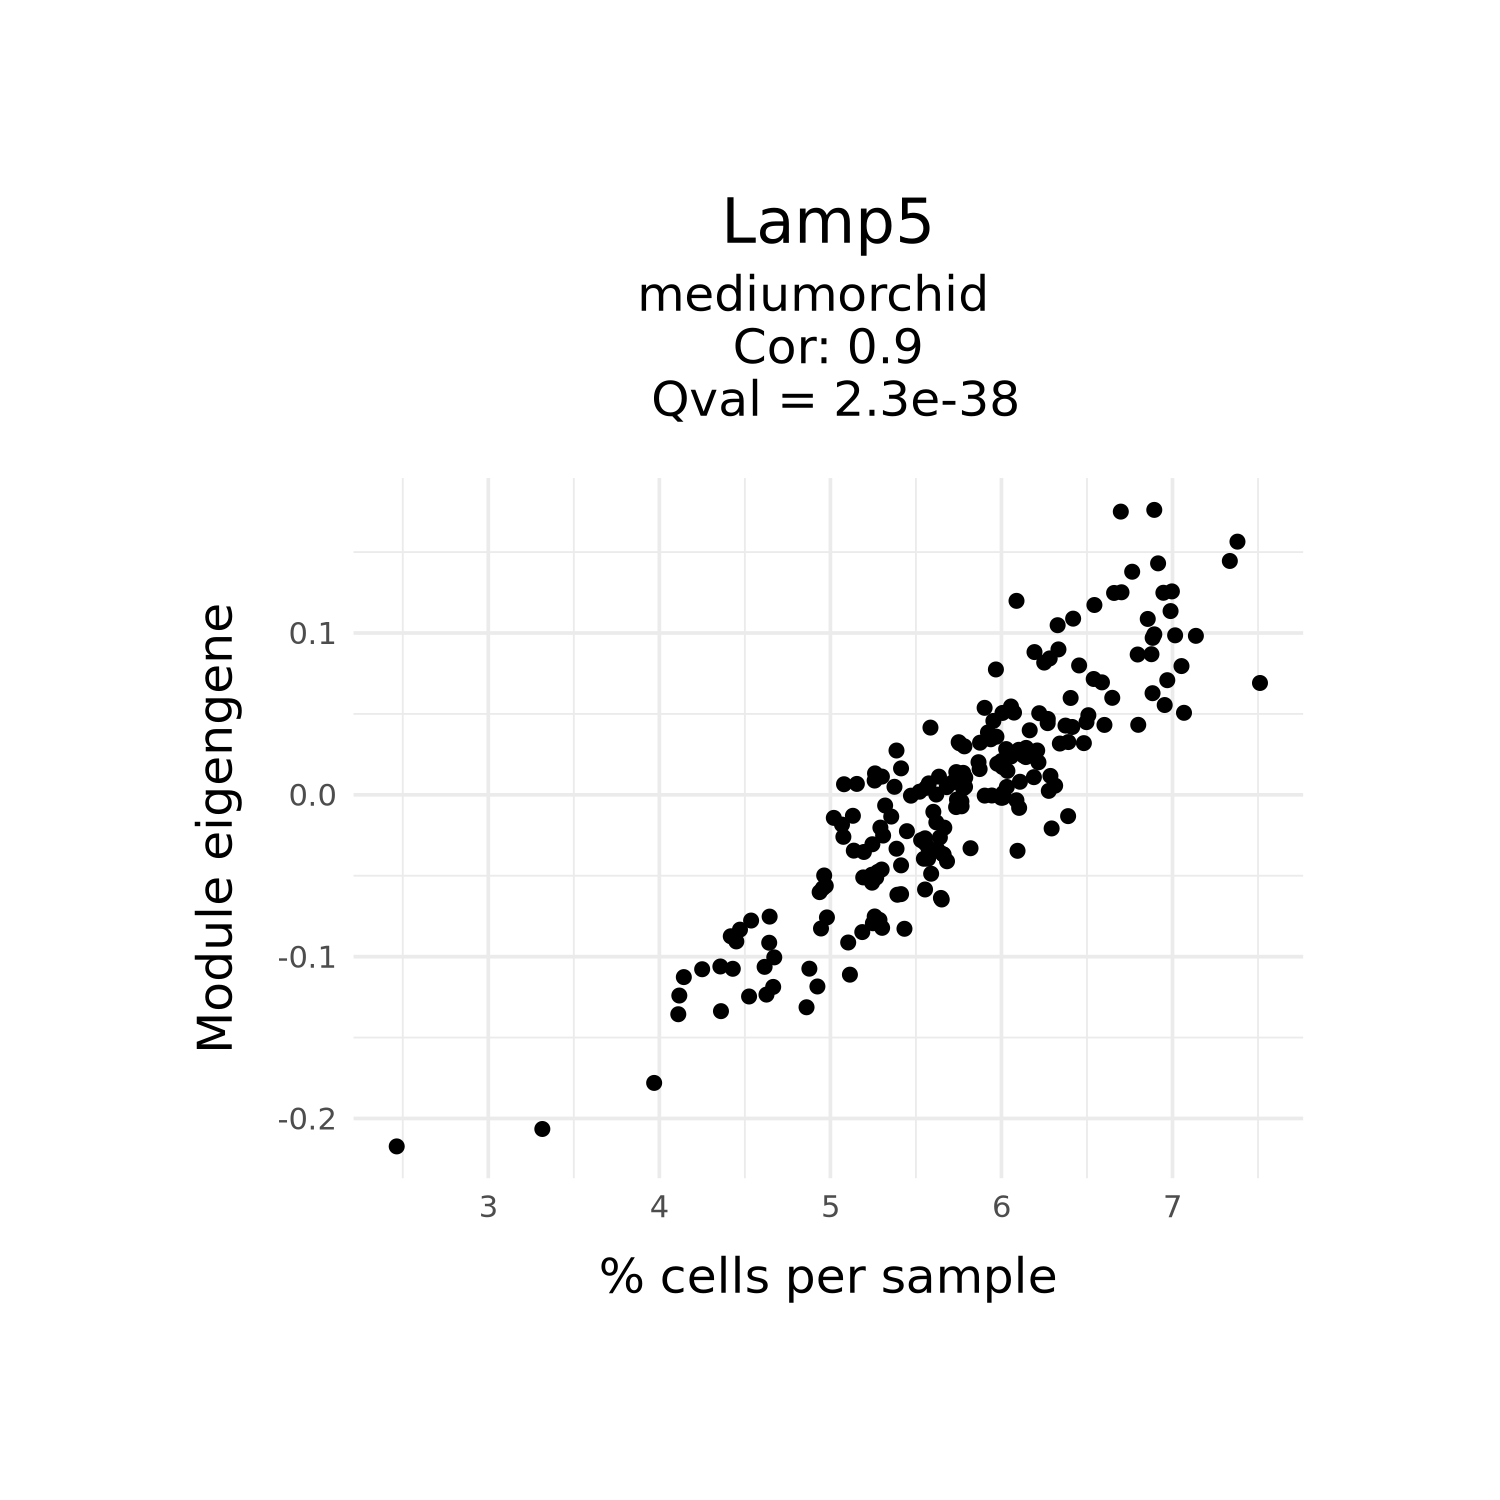

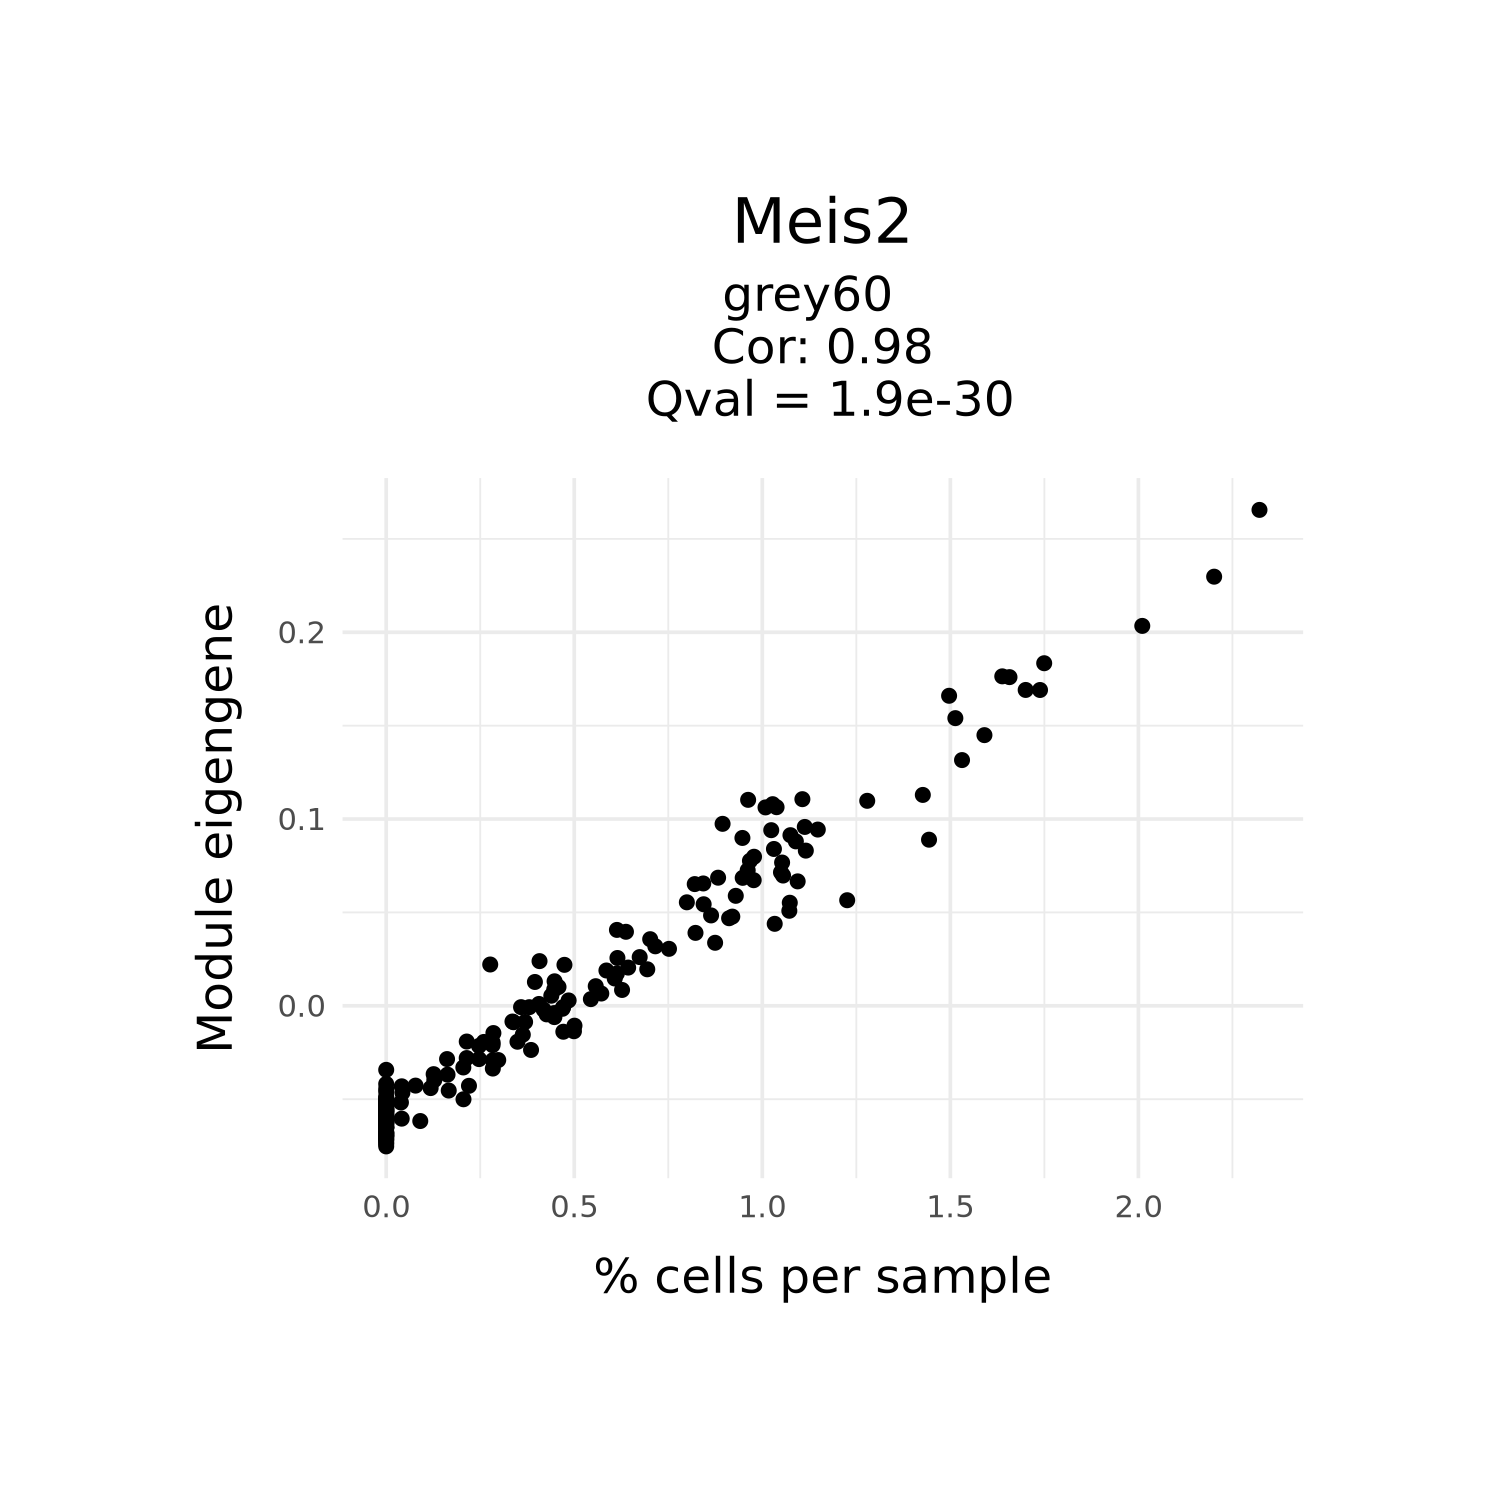

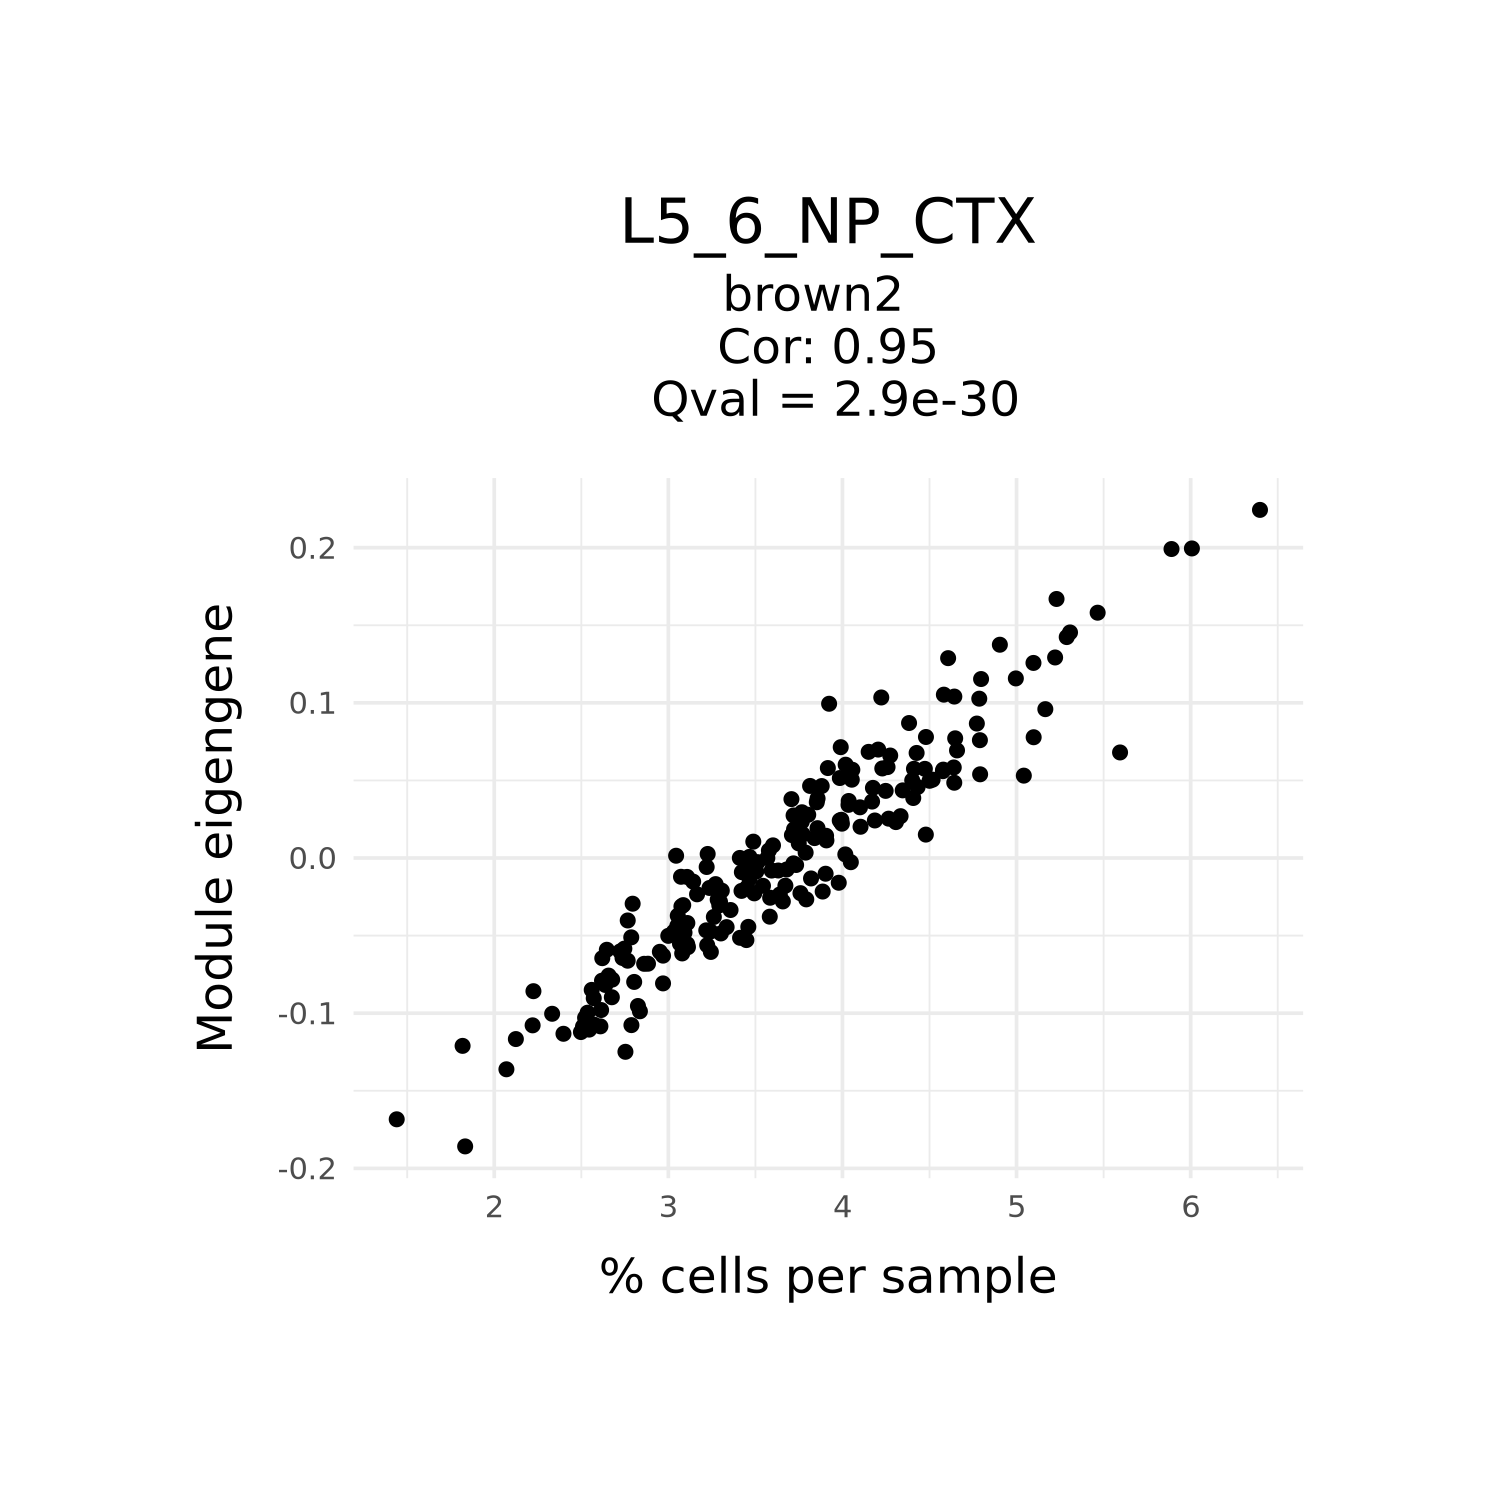

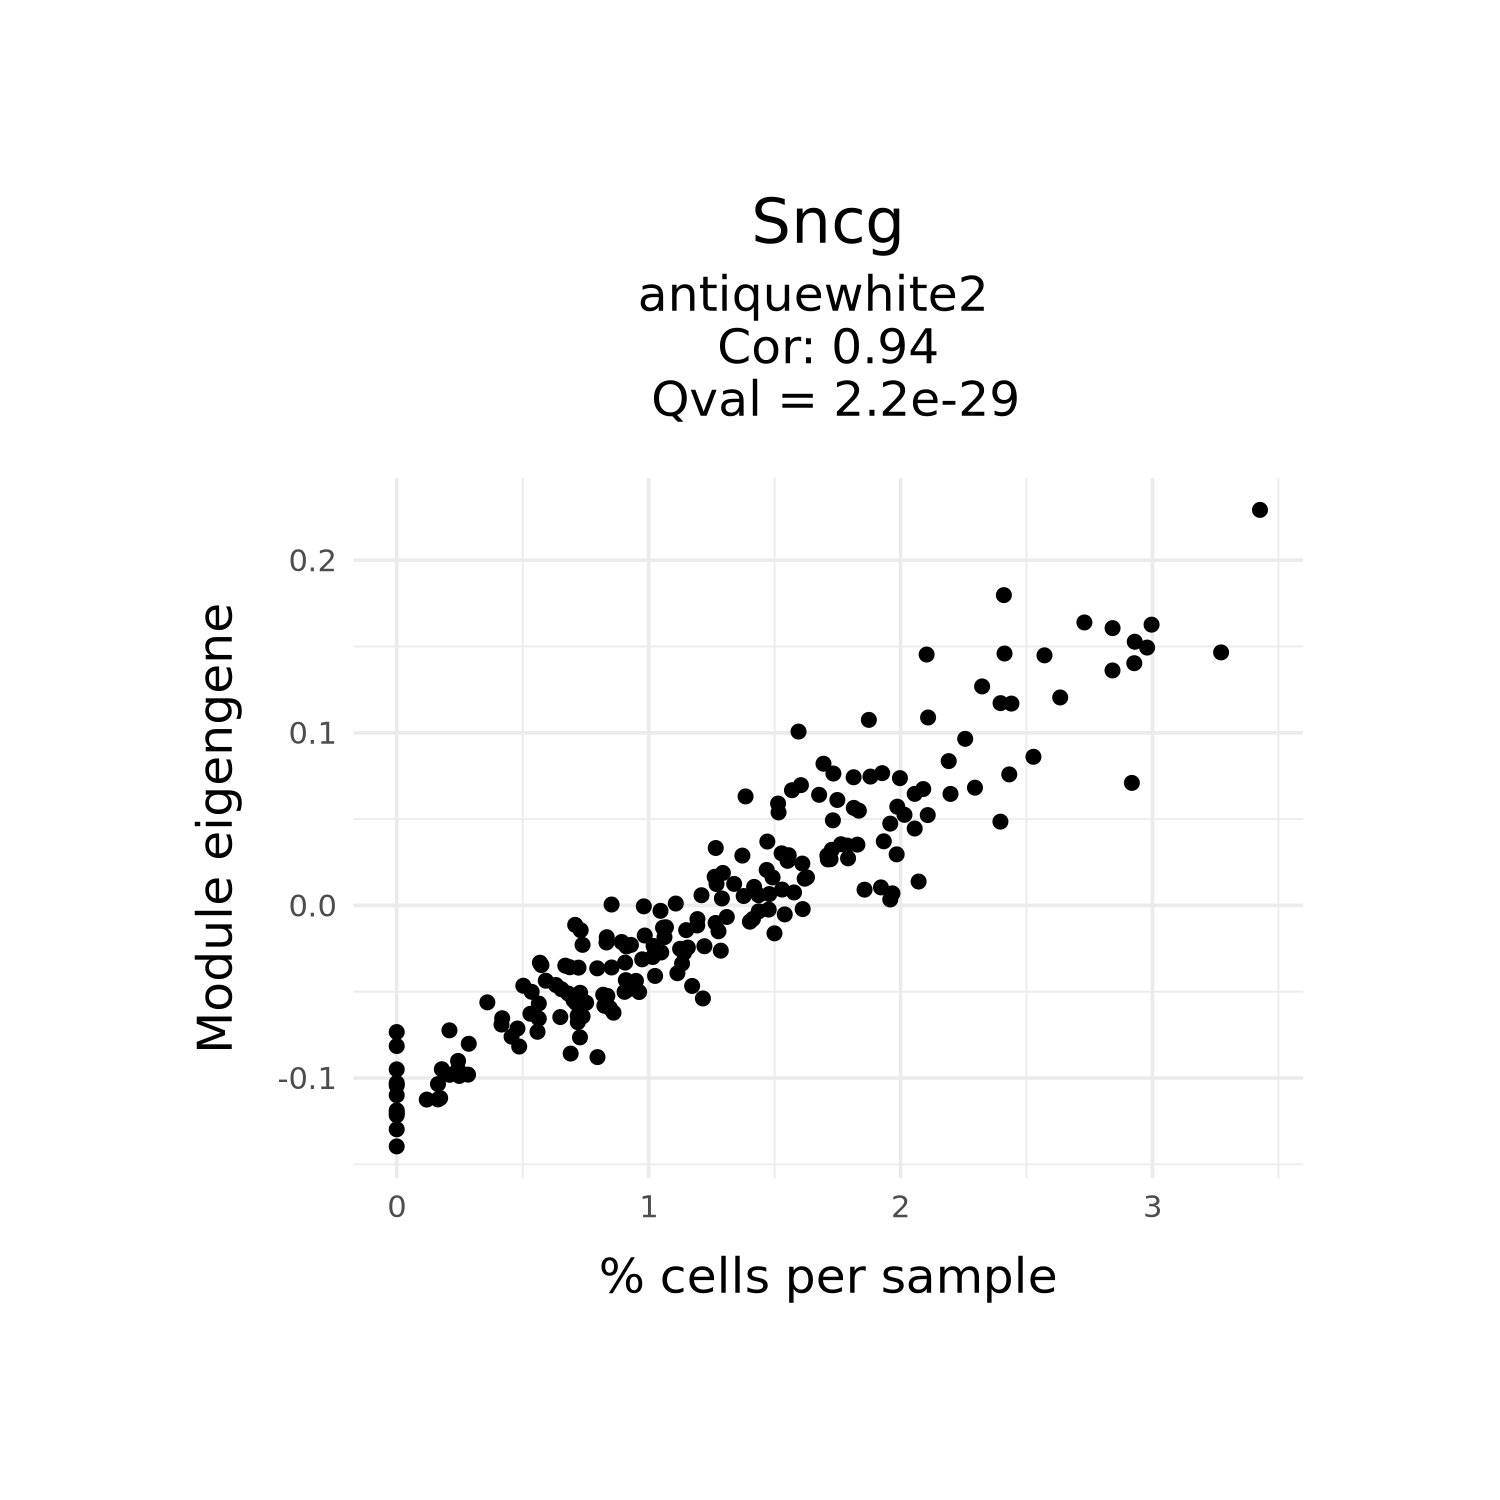

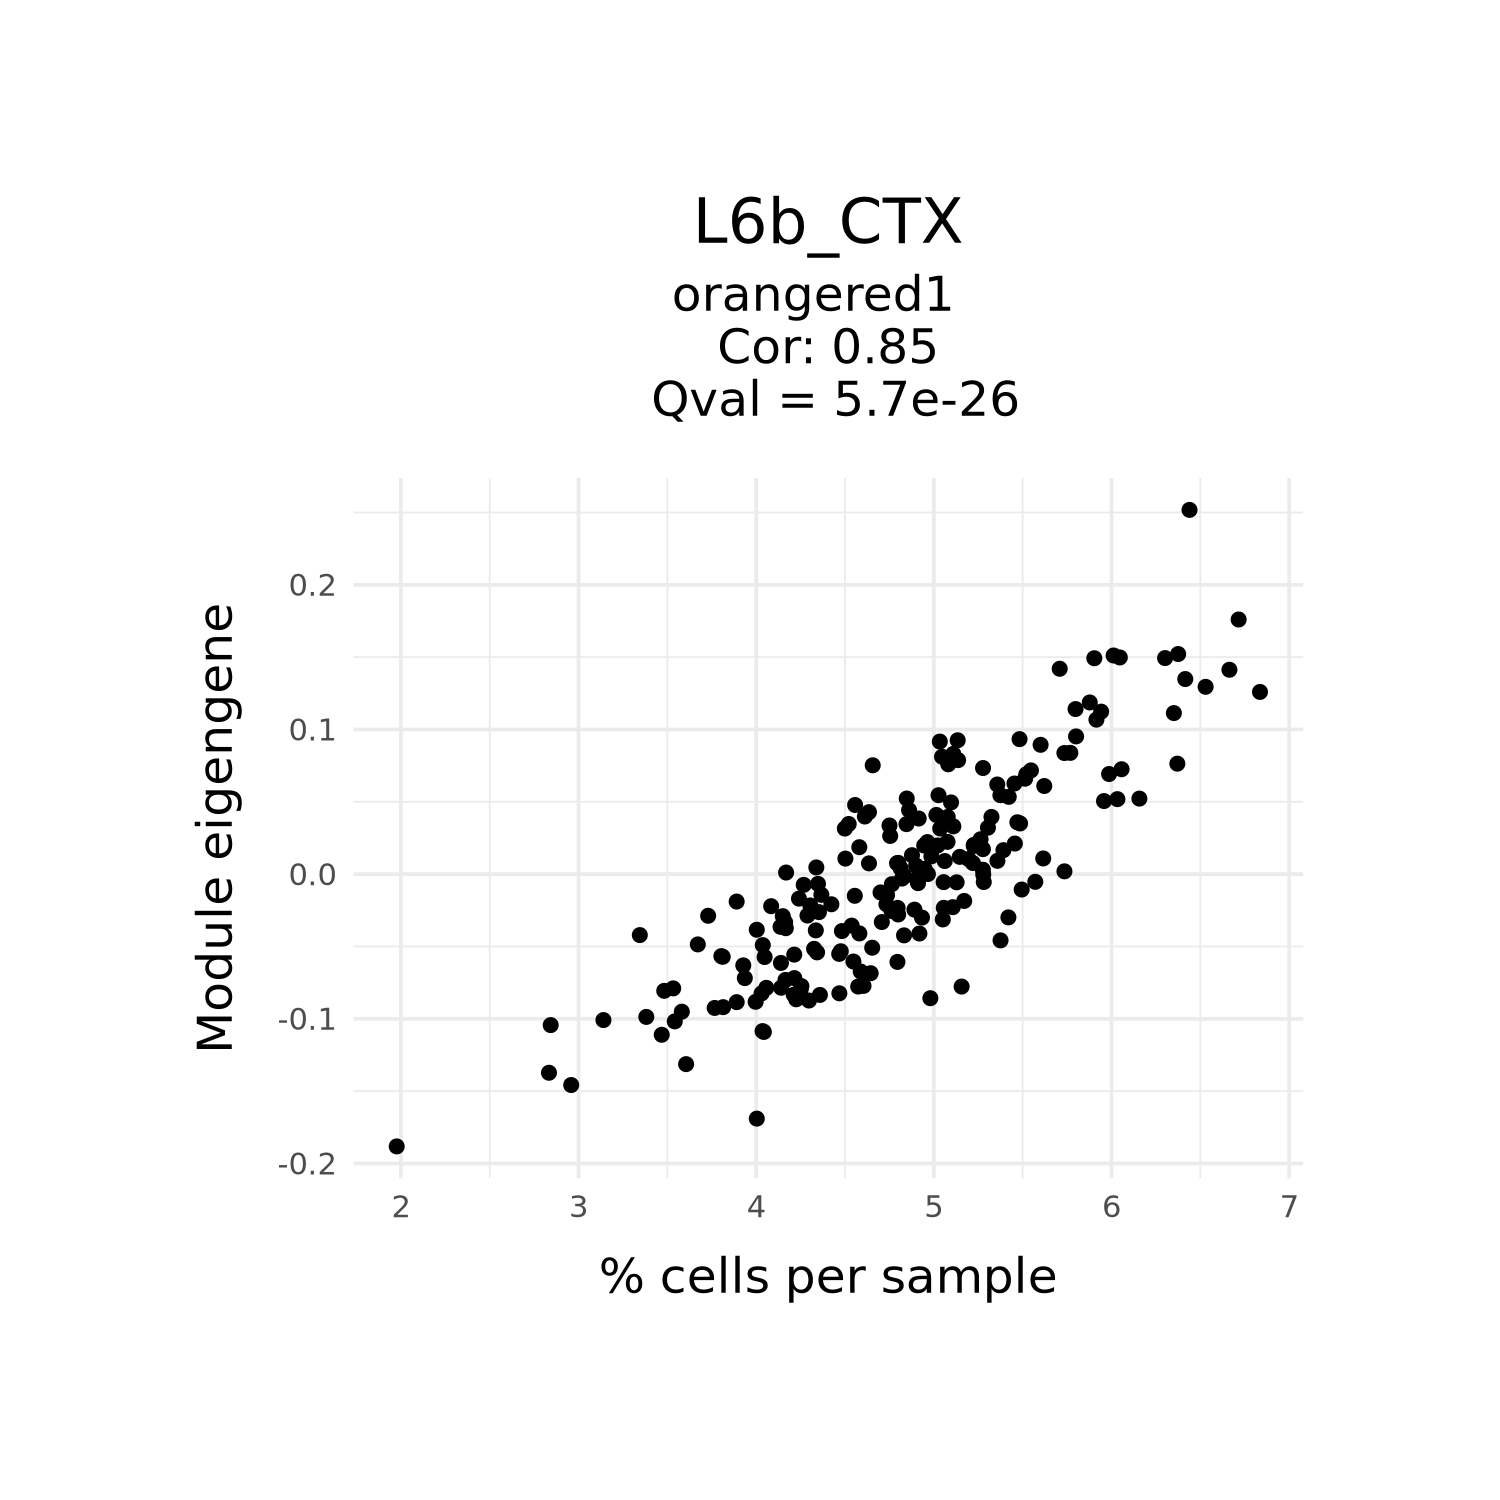

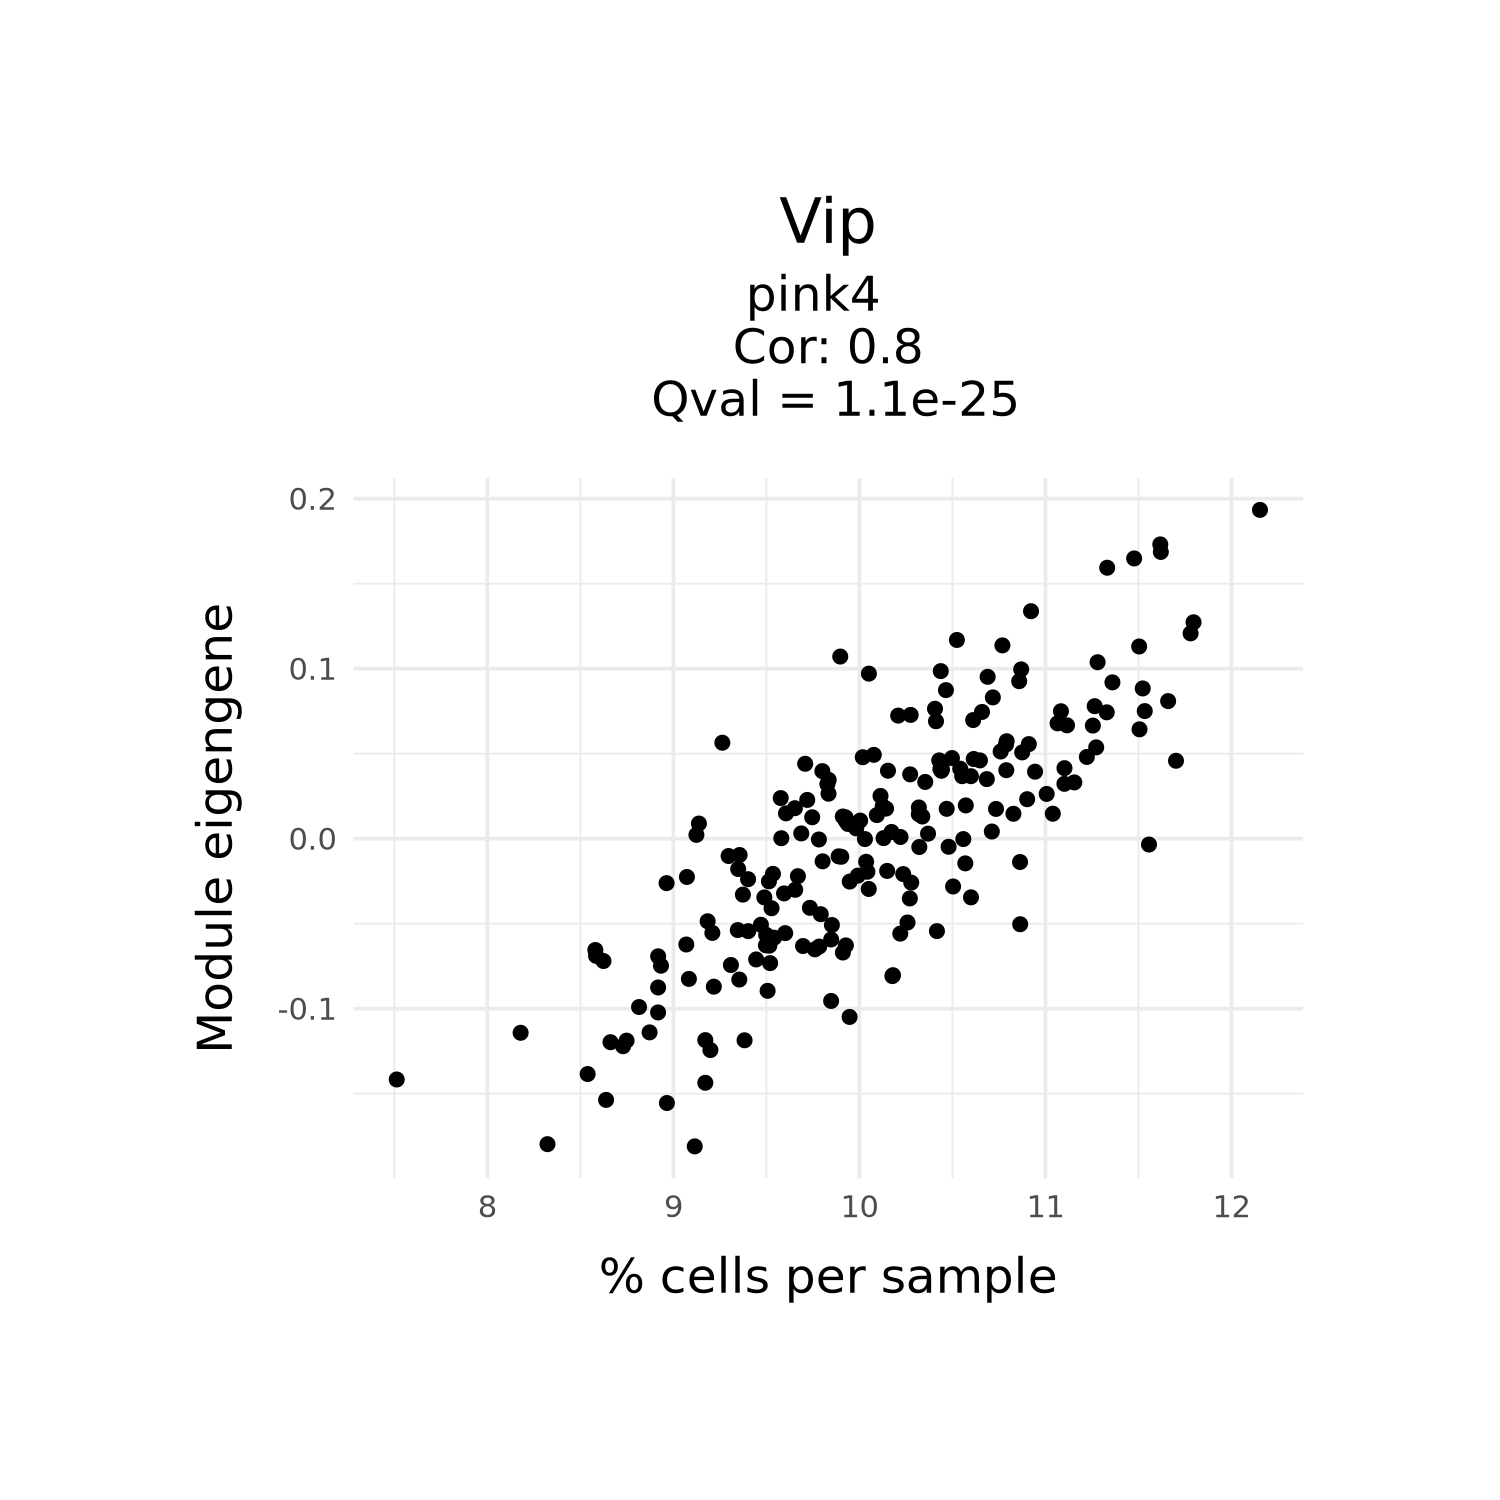

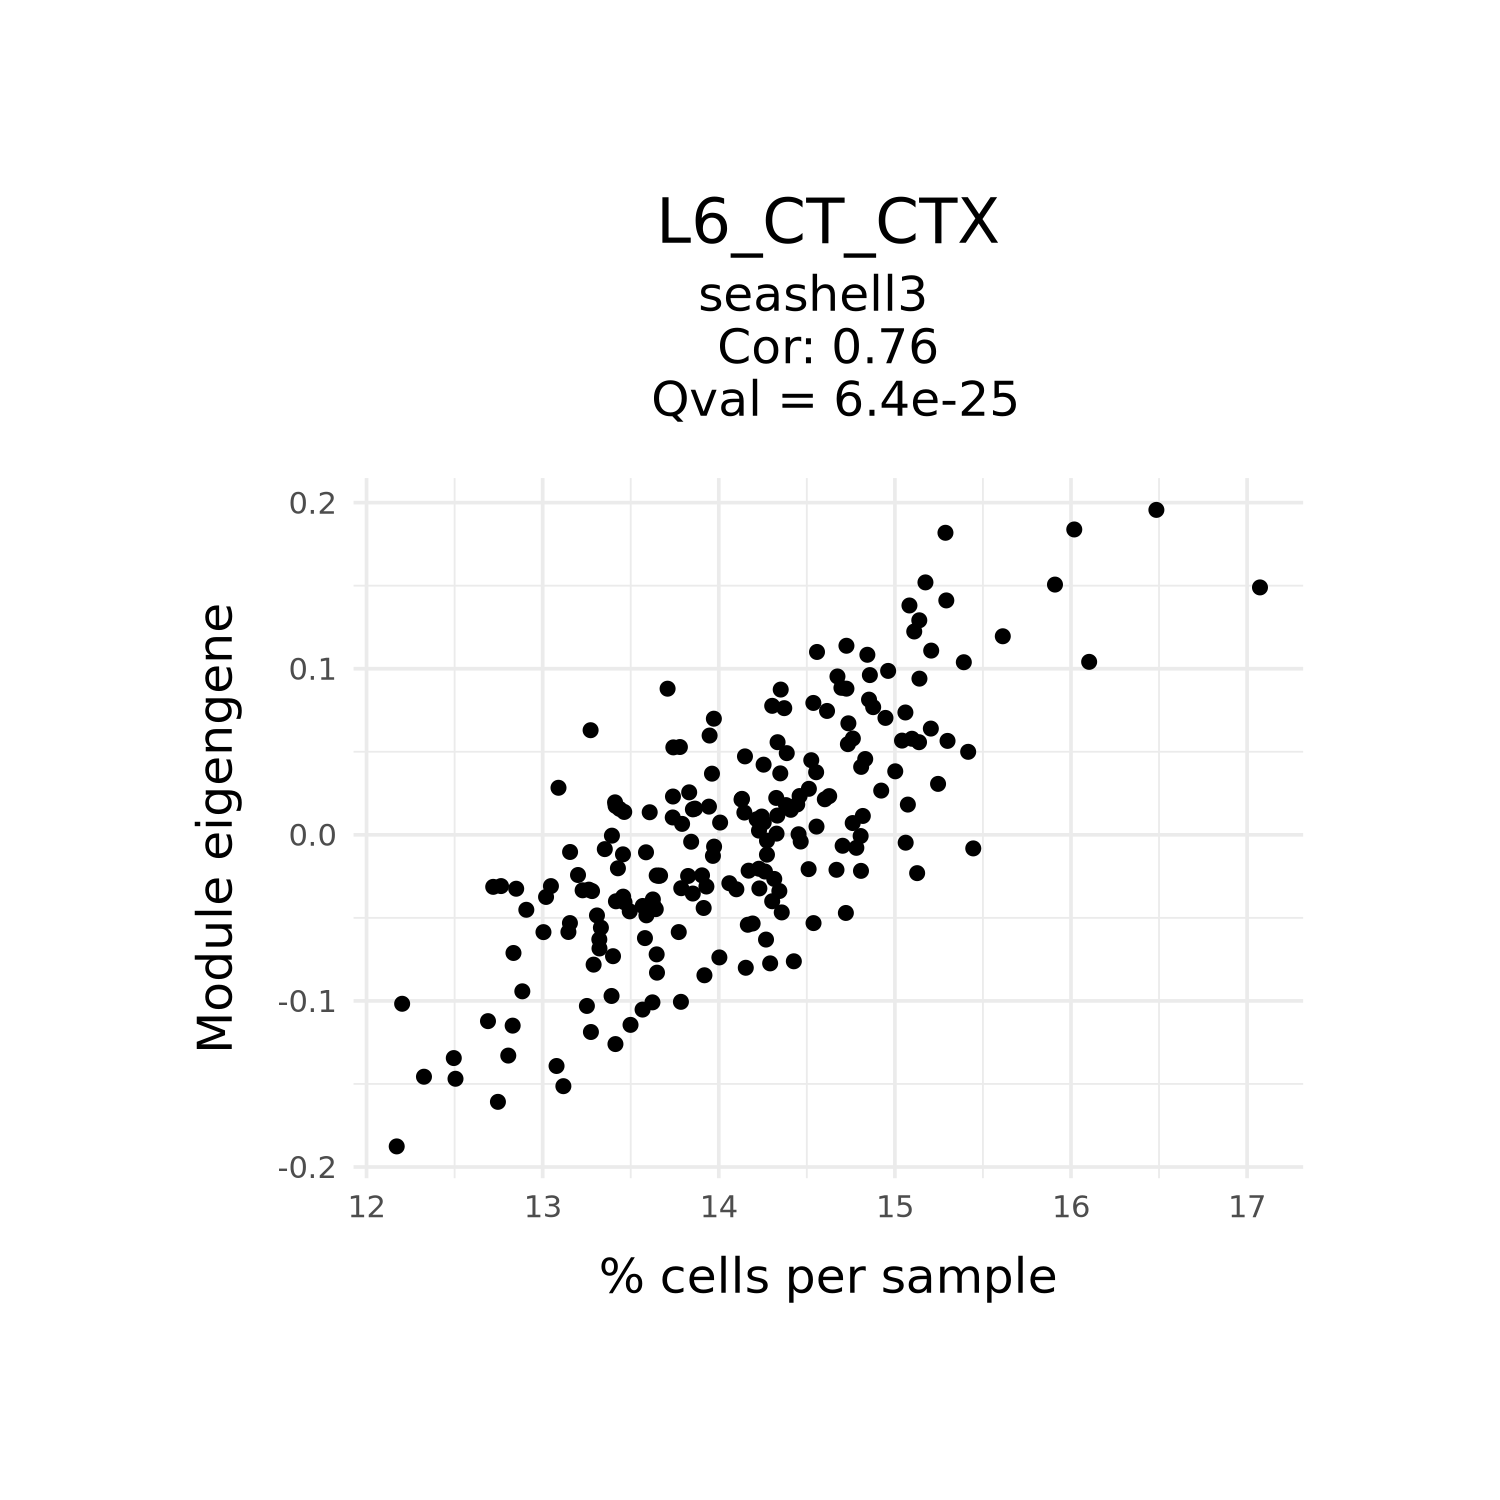

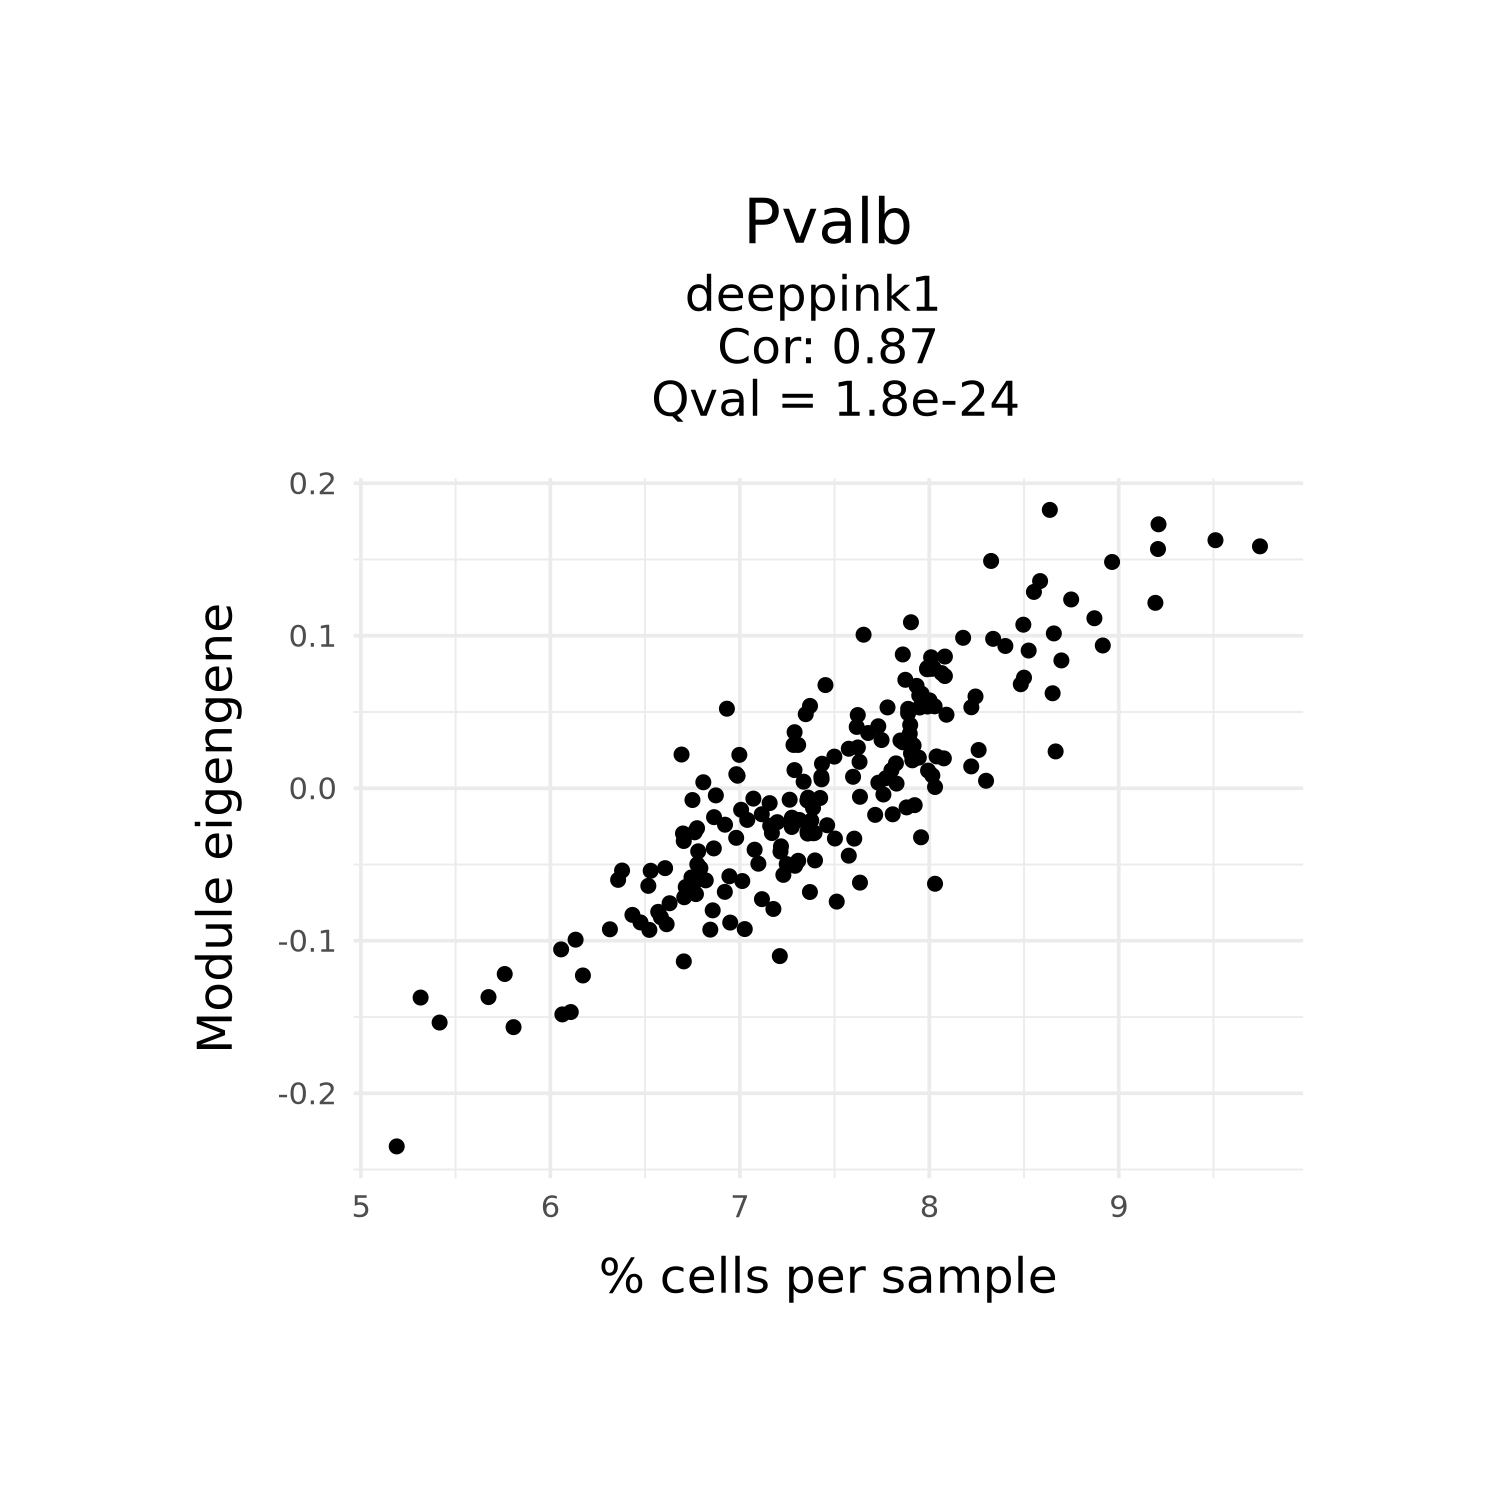

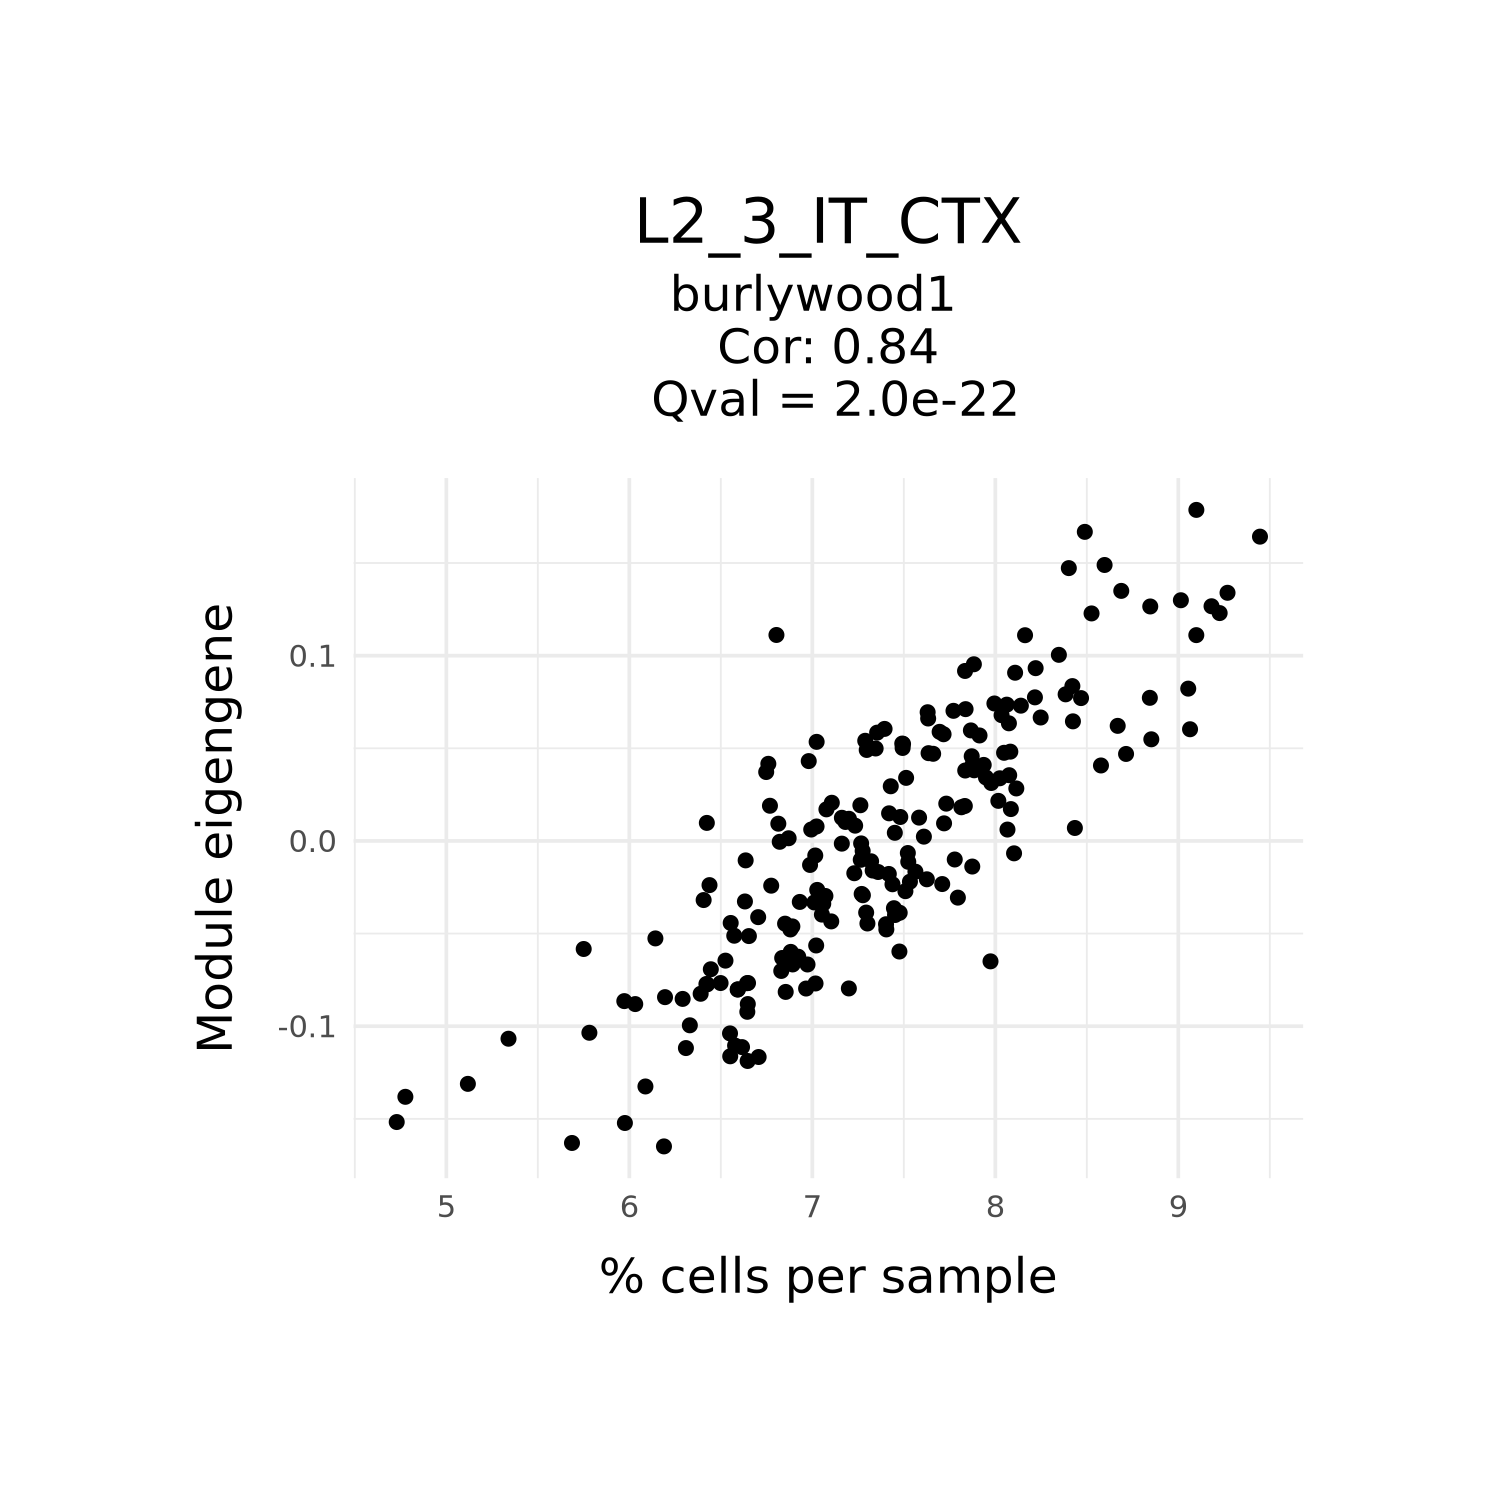

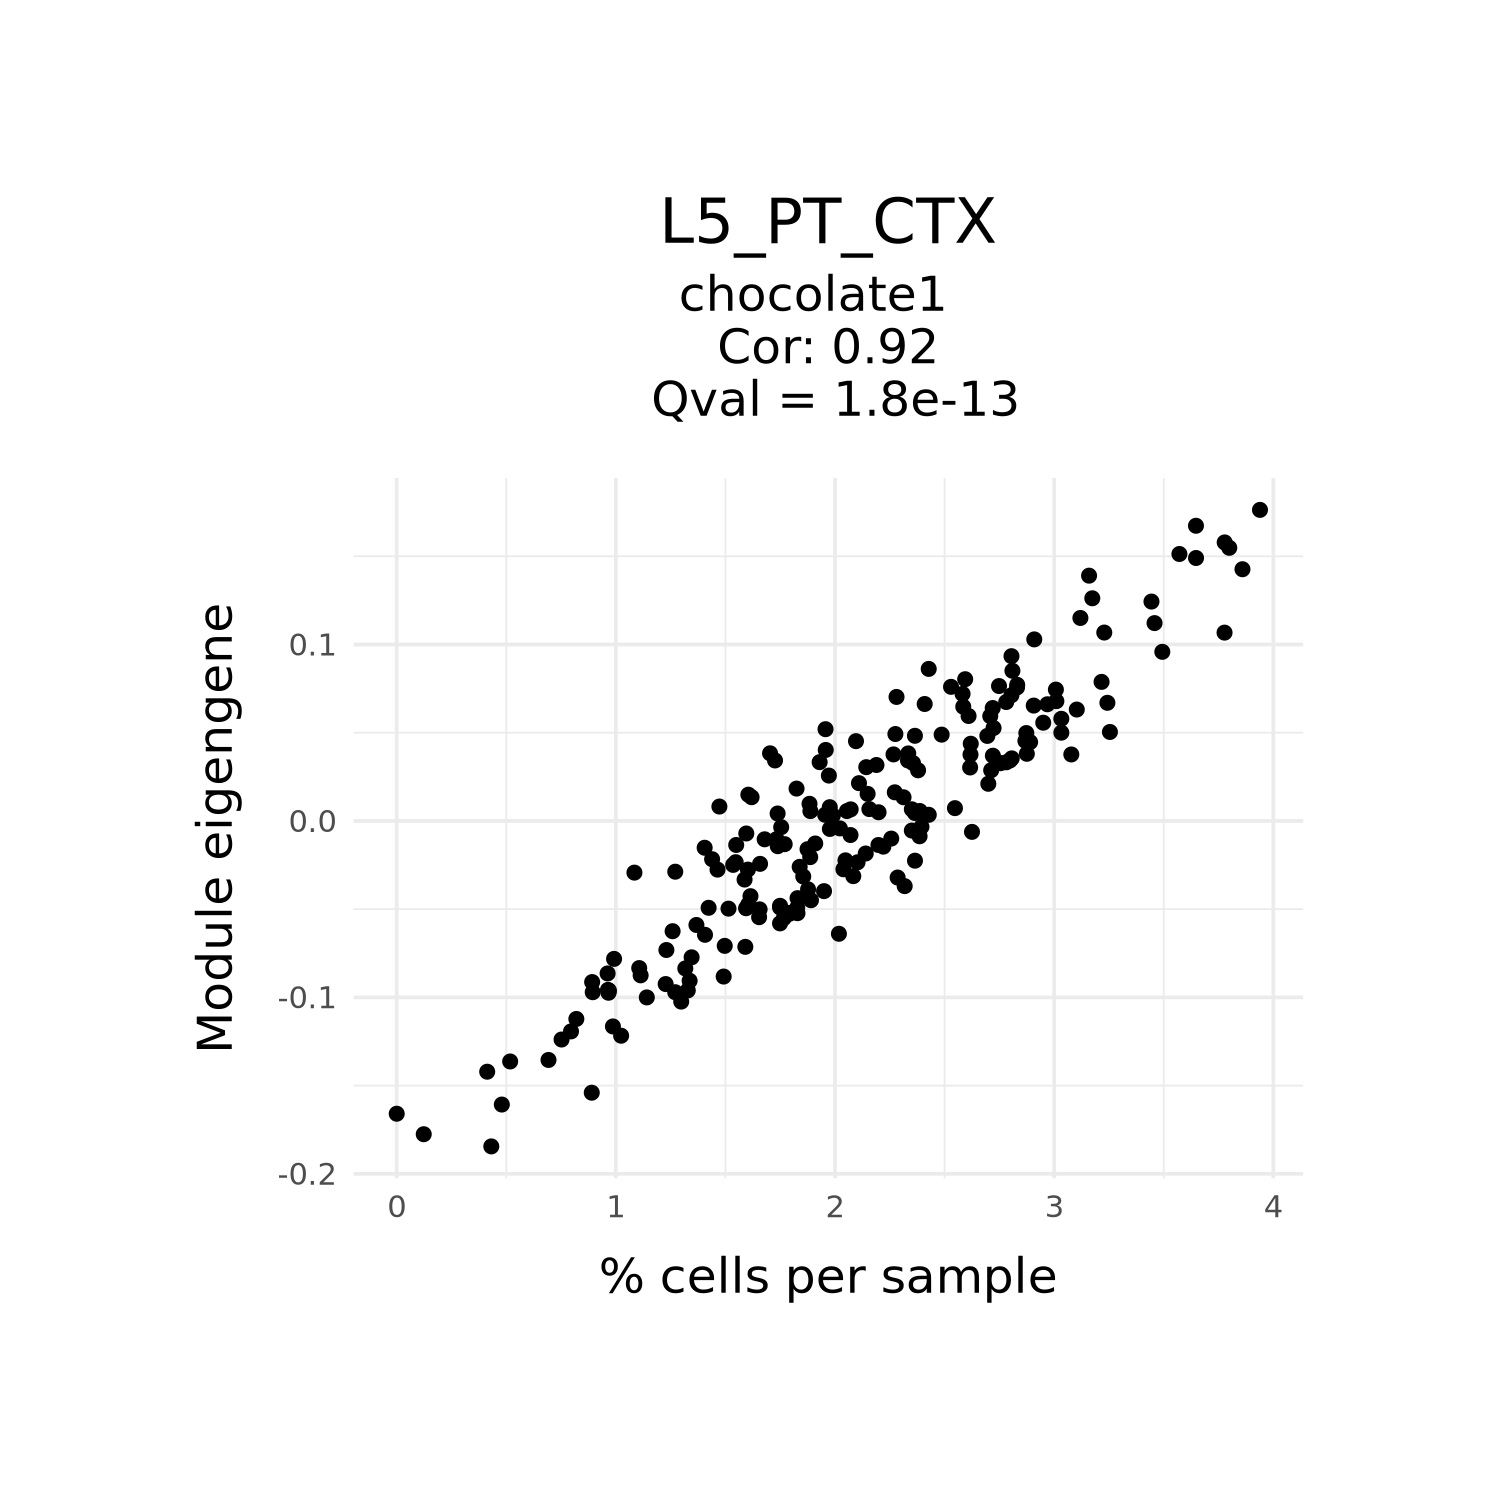

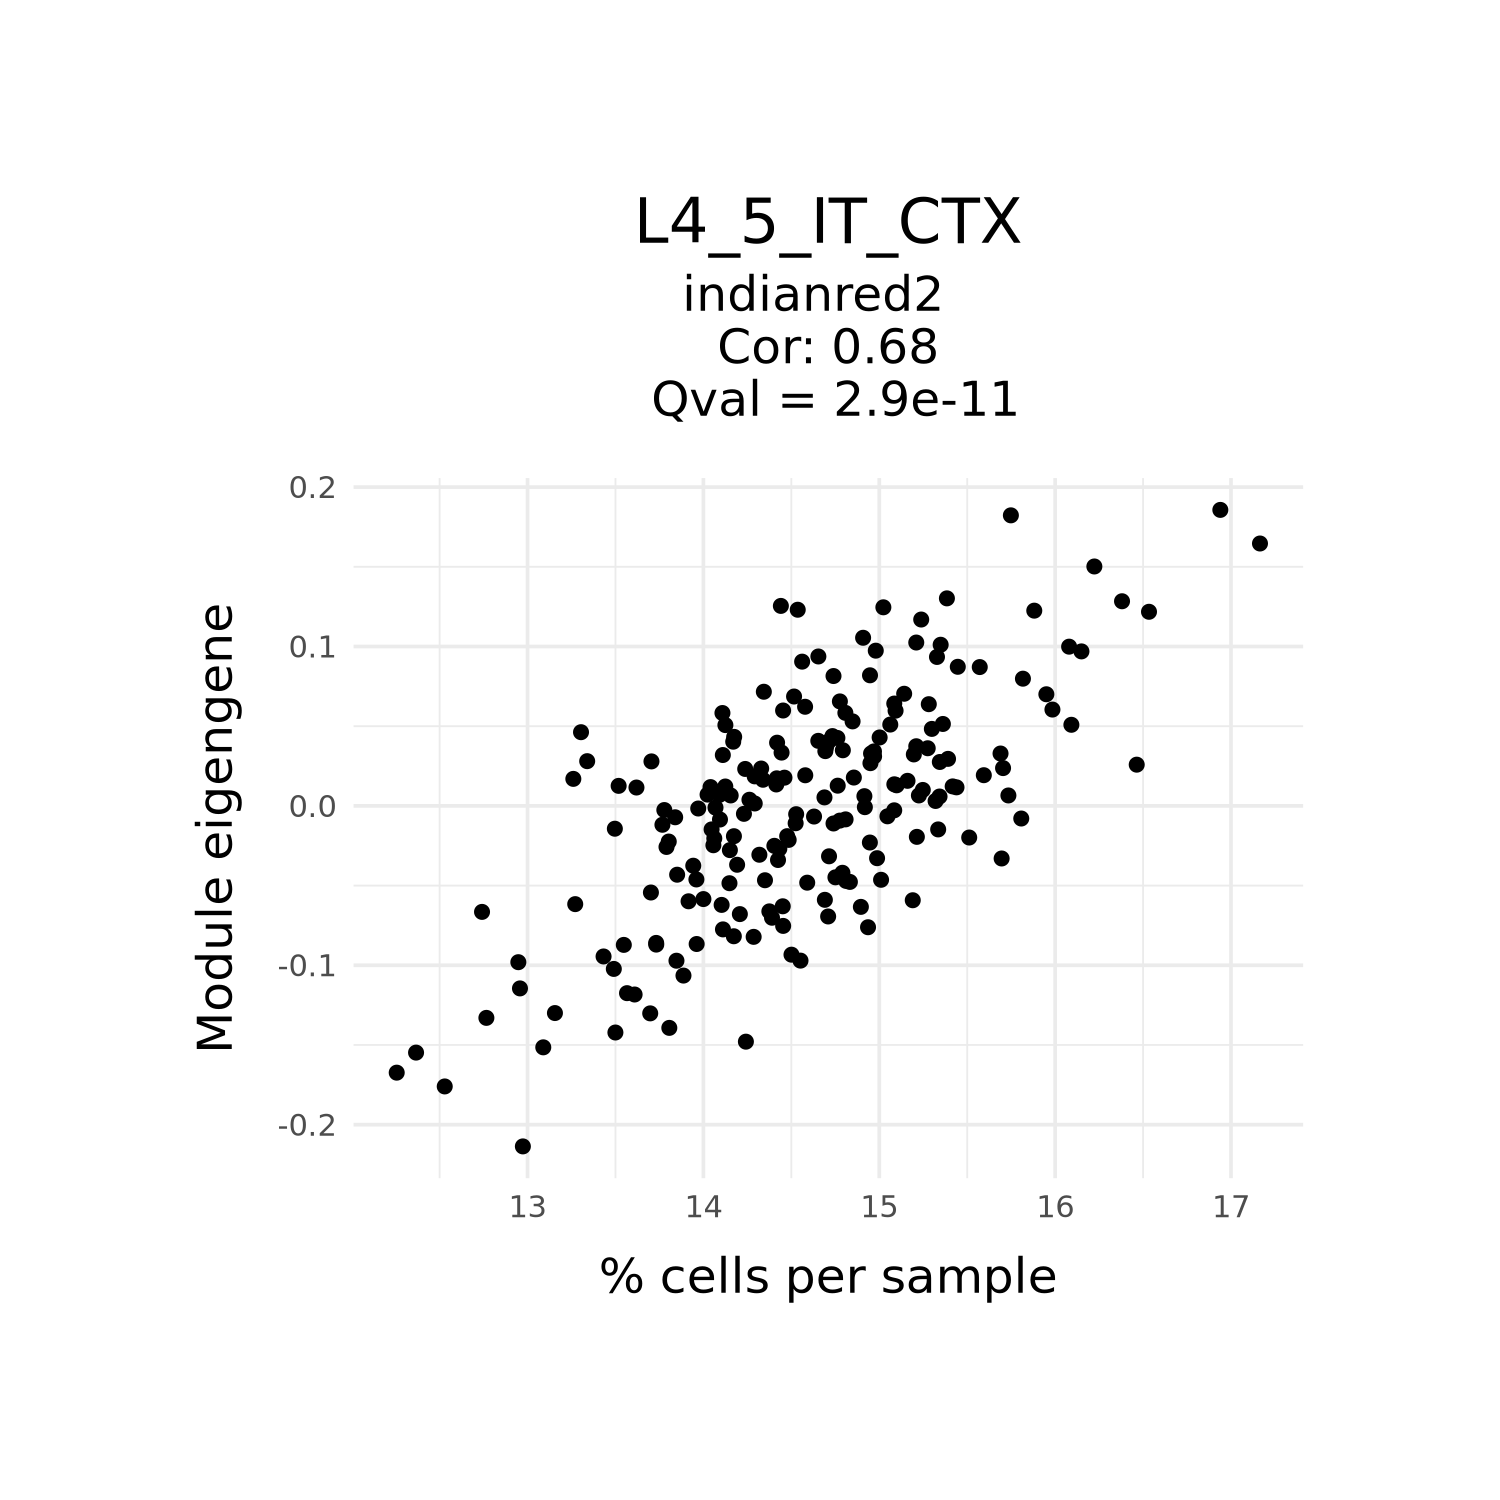

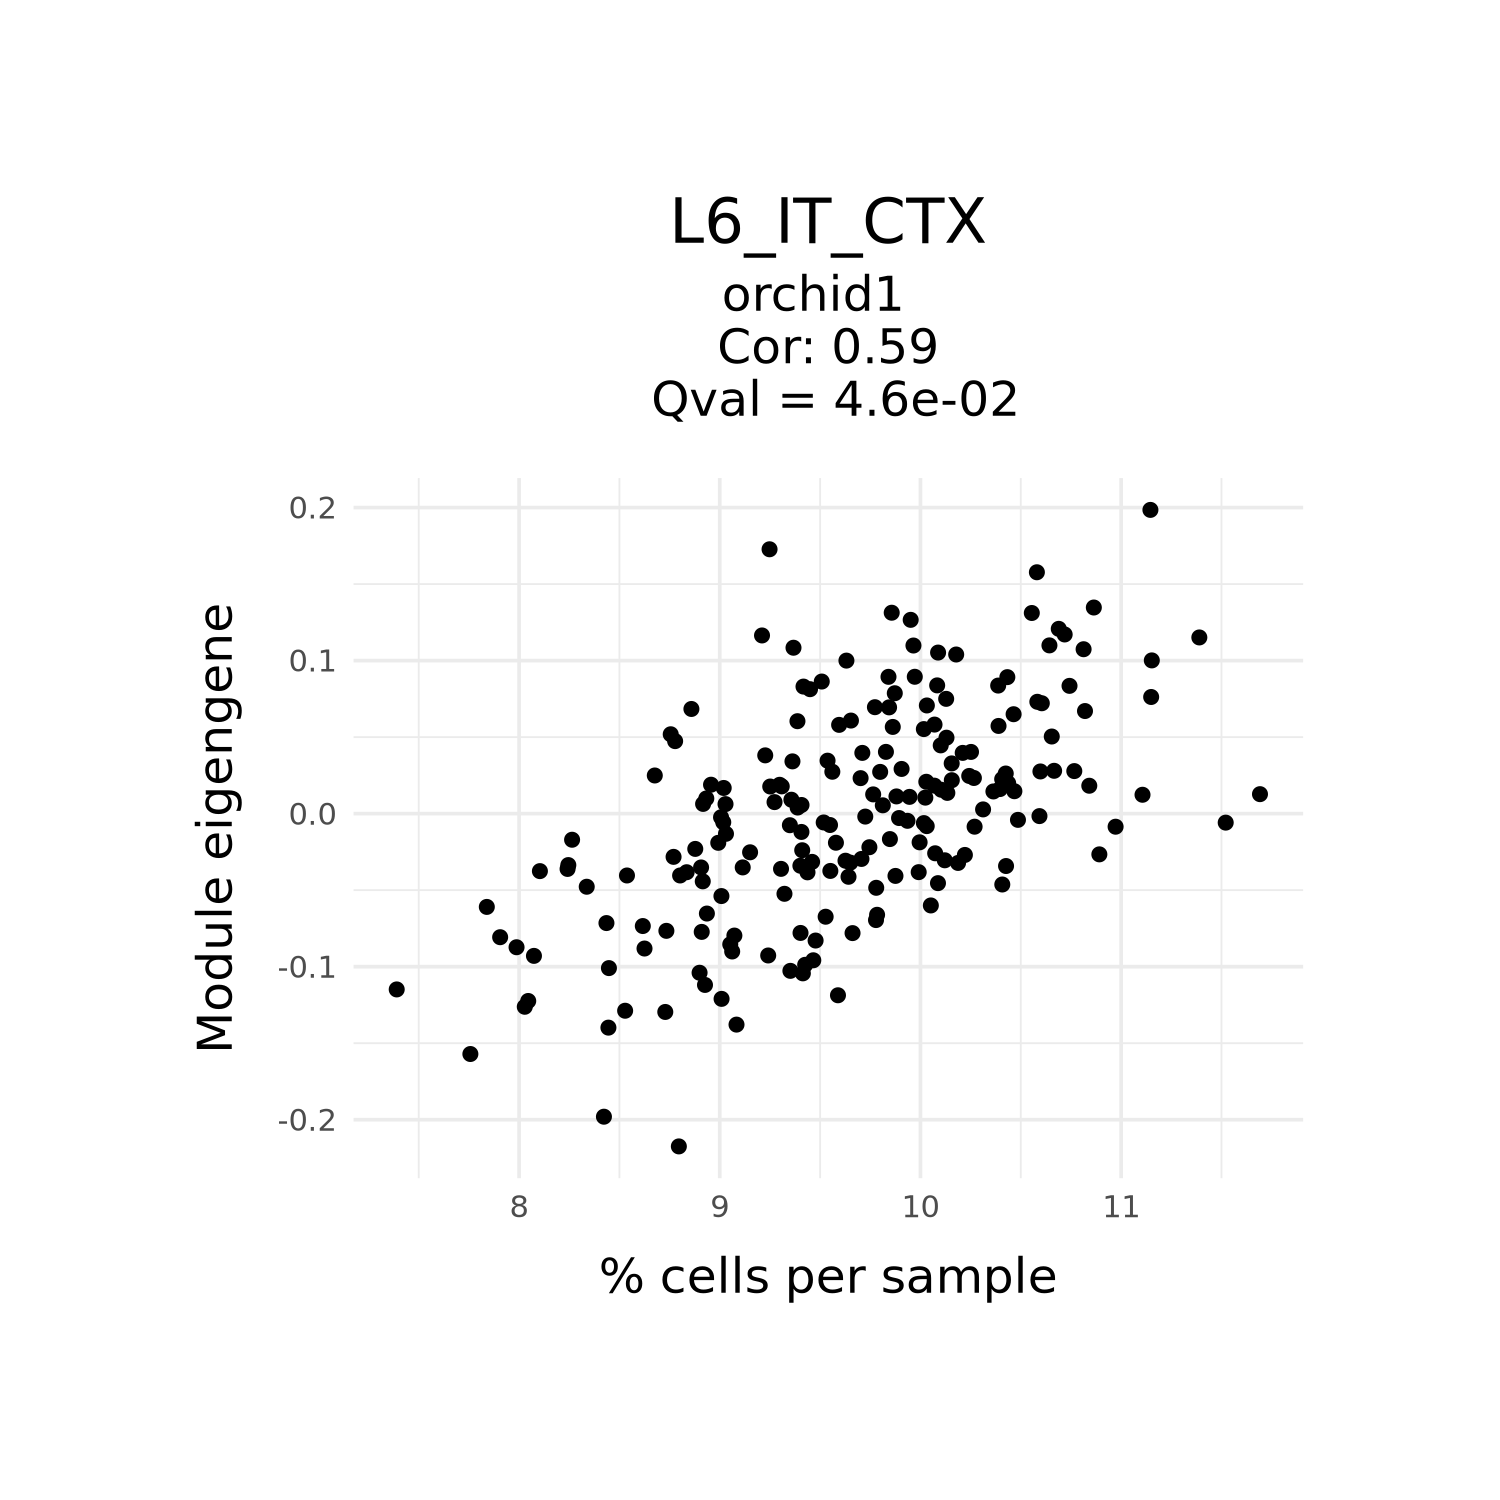

In [13]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)

## I don't use the below

Not using the below enrichments... just wanted to see if rank based enrichment would yield better hits

### fgsea 10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules

In [ ]:
network_dir <- "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_10pcntCells_20SD_200samples_legend_02-37-49.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_fgsea.csv")

In [ ]:
top_qval_mods_df$Pval <- top_qval_mods_df$Padj

In [ ]:
top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
bisque,Sst,21.31,0.8014266,0.08591673,1.251446e-18,7.000000e-50,"Calb1, Rbp4, Kctd8, Sptb, Cfap20dc, Rab27b, Col19a1, Mkx, Stxbp6, Gm31218, Fibcd1, Cdh7, Minar1, 9630002D21Rik, Hunk","Gm17396, Rbms3, Lbh, Dipk1a, Dpysl3, Mrps6, Ankrd50, Trpc4, Slco3a1, Epha1, NA, NA, NA, NA, NA","1700086L19Rik-1, 2610318N02Rik, 4930426D05Rik, 8030443G20Rik, 9330158H04Rik, 9430021M05Rik, 9630002D21Rik, A230077H06Rik, A2ml1, A530058N18Rik-1, A930003A15Rik, Abtb3, Ache, Acrbp, Ada",bisque,gray81,Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409,Bicor-None_signum0.3_minSize4_merge_ME_0.95_18409,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409/Module_eigengenes_04-27-35.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.3_minSize4_merge_ME_0.95_18409/Module_eigengenes_05-34-11.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize4_merge_ME_0.95_18409/kME_table_04-27-35.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.3_minSize4_merge_ME_0.95_18409/kME_table_05-34-11.csv
brown11,Astro,16.86,0.9947795,0.16686063,1.247691e-274,3.500000e-50,"Ntsr2, F3, Prdx6, Slc7a10, Cldn10, Aldoc, Htra1, Gpr37l1, Mt2, Dio2, Plpp3, Gm45774, Mlc1, Gm6145, Slc27a1","Dynlt1-ps1, Dynlt1b, Vezf1, Ubr1, Clcc1, Pkn2, Smc4, Mbtps1, Ubxn1, Ube2r2, H2-K2, Gm57402, 4930503L19Rik, Rad9a, Ssr1","1700003M07Rik, 1700071M16Rik, 2810403D21Rik, 2900052N01Rik, 3110082J24Rik, 4930488L21Rik, 9330121J05Rik, 9430041J12Rik, AA387883, Aass, Abca1, Abhd3, Acot11, Acsbg1, Acss1",brown,deepskyblue,Bicor-None_signum0.438_minSize10_merge_ME_0.95_18409,Bicor-None_signum0.24_minSize6_merge_ME_0.95_18409,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize10_merge_ME_0.95_18409/Module_eigengenes_04-52-20.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.24_minSize6_merge_ME_0.95_18409/Module_eigengenes_06-49-56.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.438_minSize10_merge_ME_0.95_18409/kME_table_04-52-20.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules/Bicor-None_signum0.24_minSize6_merge_ME_0.95_18409/kME_table_06-49-56.csv
mediumorchid2,L6_IT_CTX,19.72,0.6487180,0.58644290,1.000000e+00,1.770380e-03,"Slc7a4, Ak5, Pfkl, Igsf21, Necab3, Gpr52, Sulf1, Slc26a10, Fancd2os, Prss22, Bmp3, Cwh43, Syt12, Kazald1, AI115009","C1ql3, Gm37811, Pter, Mas1, Rtn4rl2, Adgrd1, Adamts13, Slc26a4, Gm48695, Gm37824, NA, NA, NA, NA, NA","

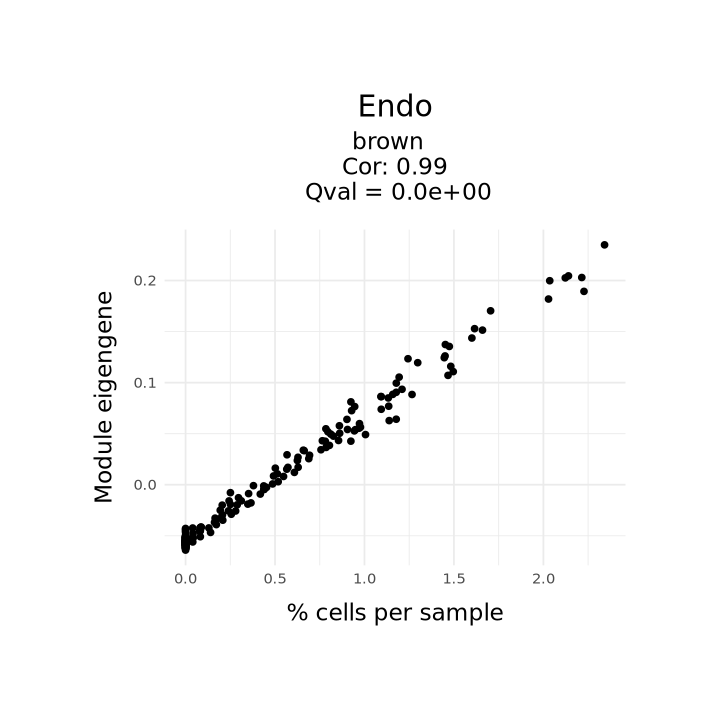

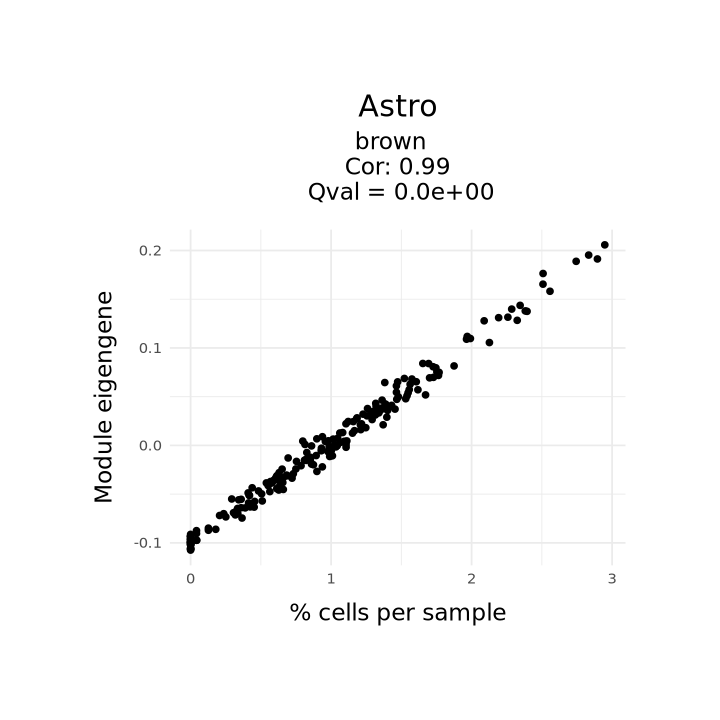

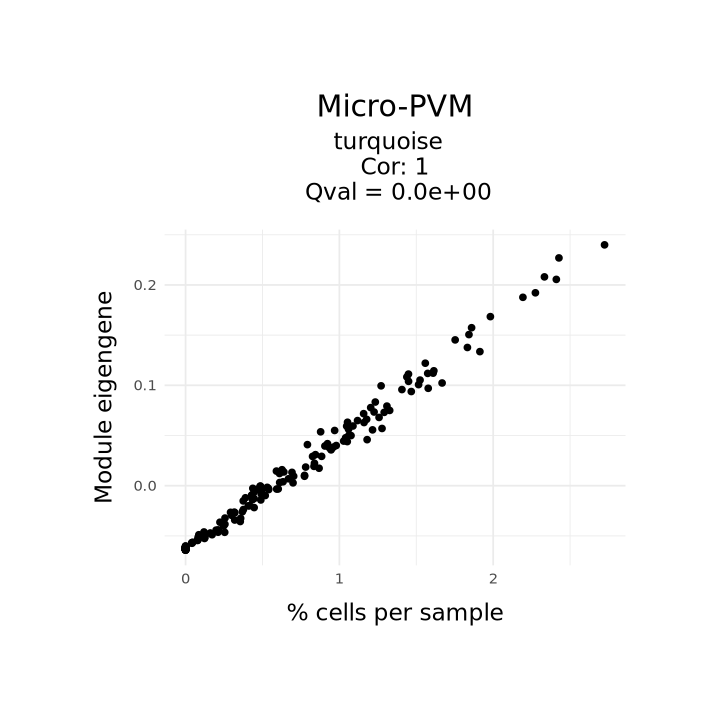

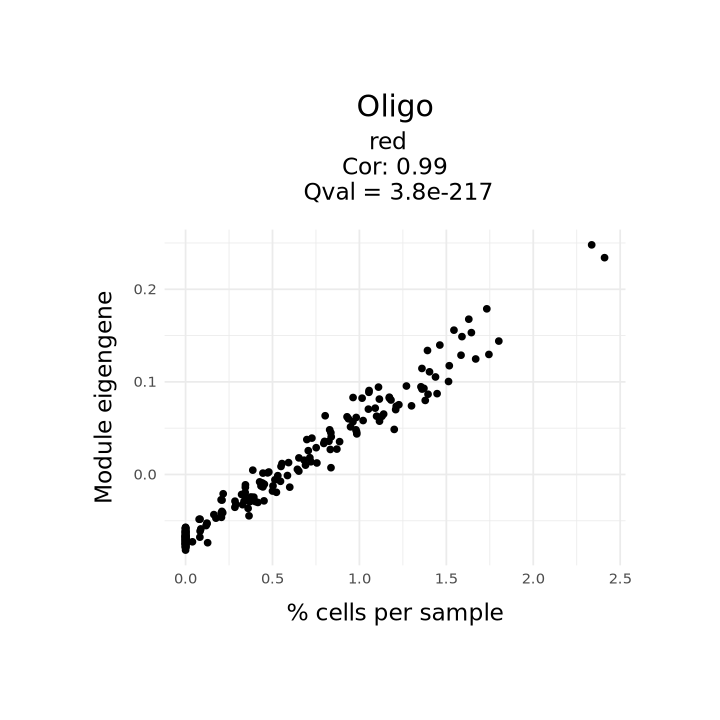

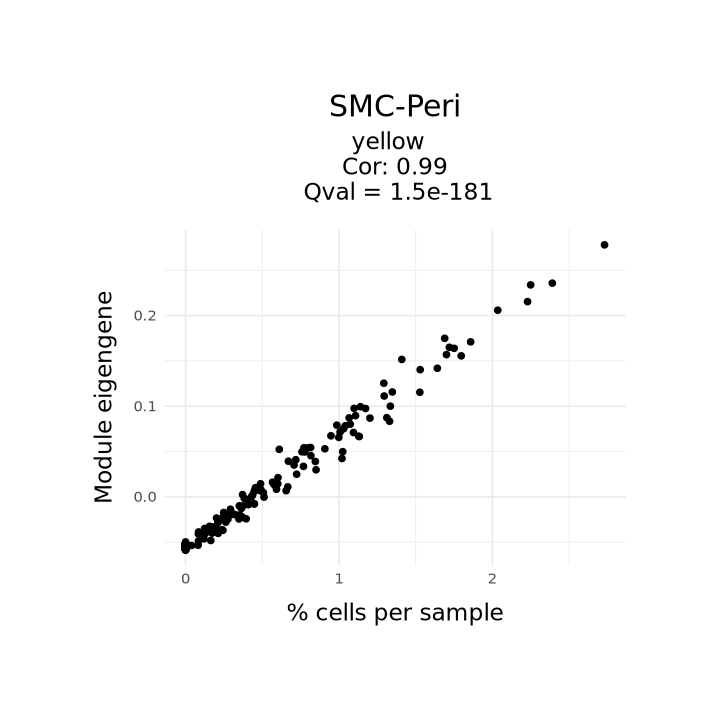

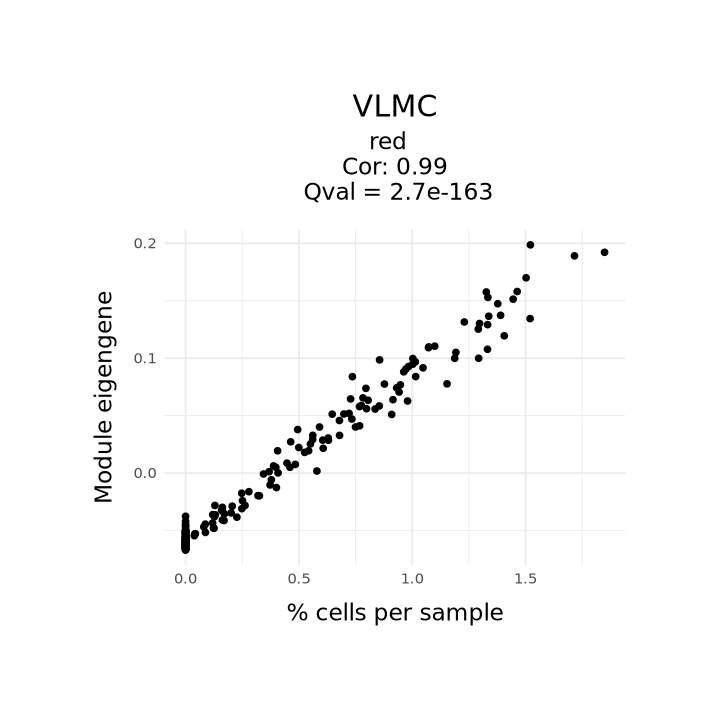

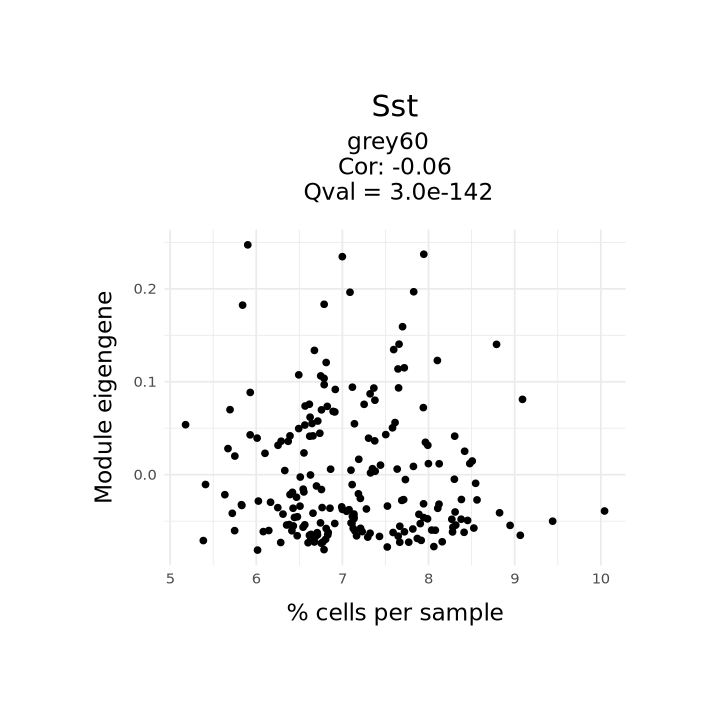

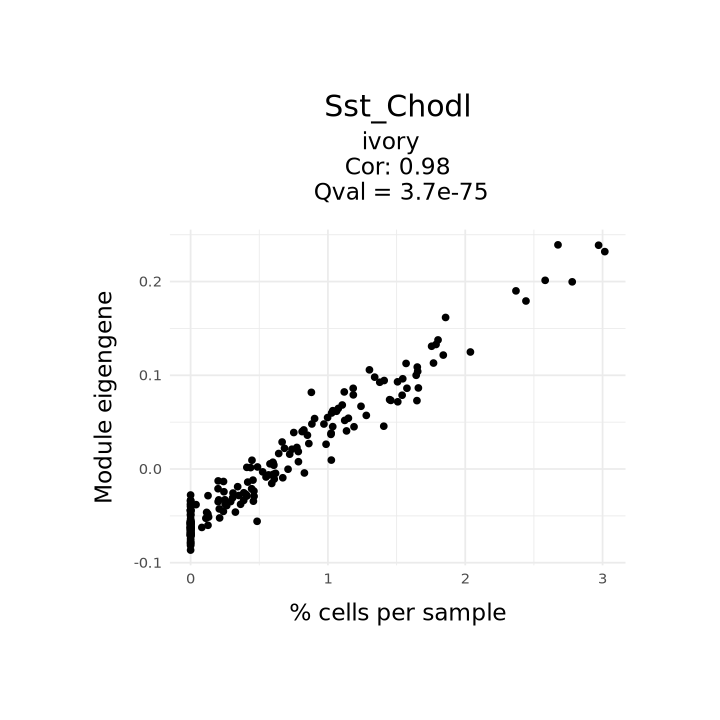

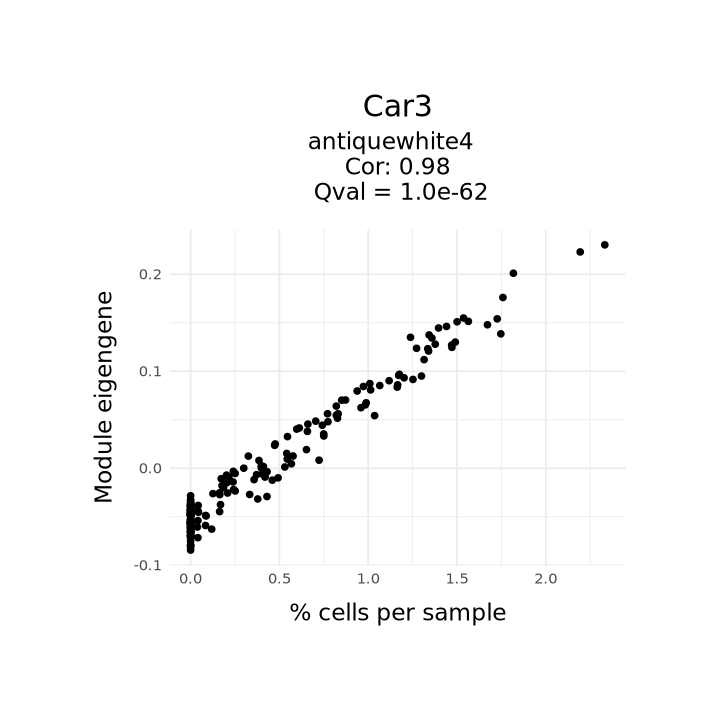

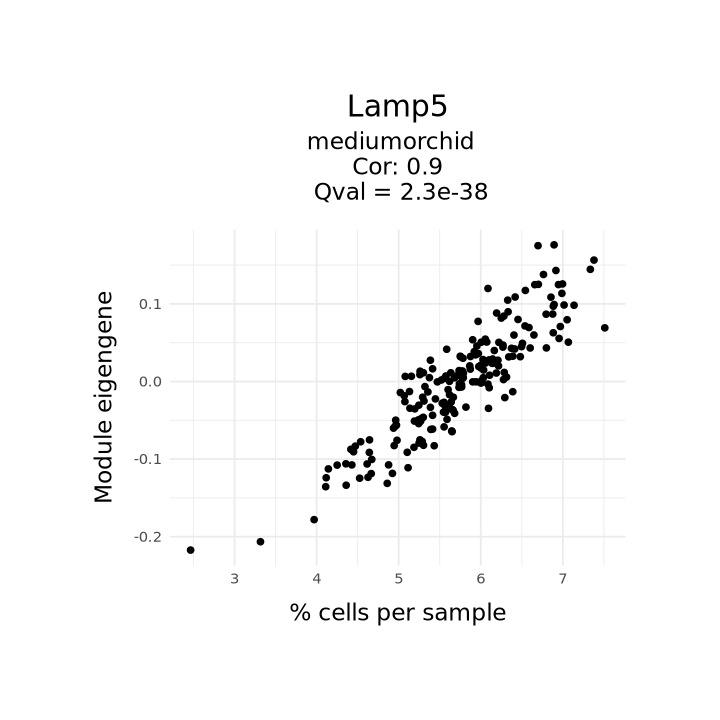

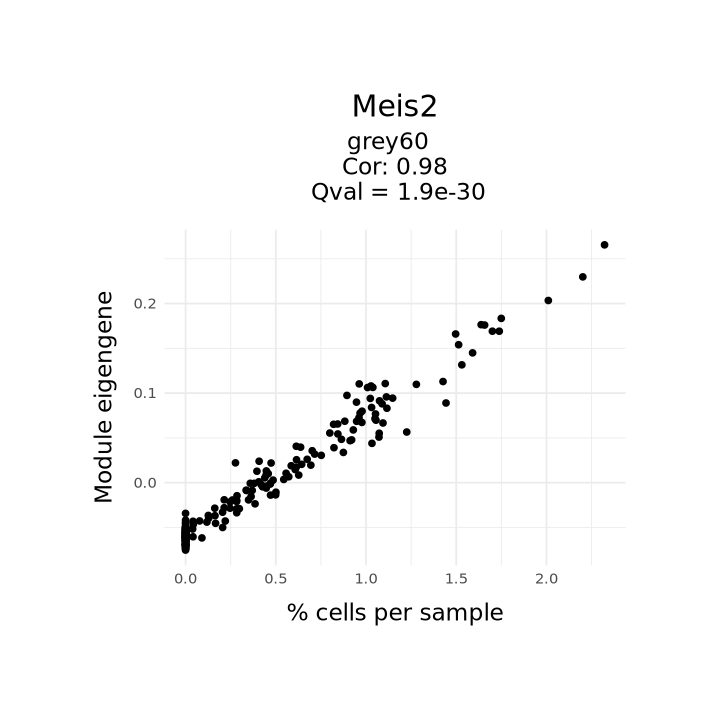

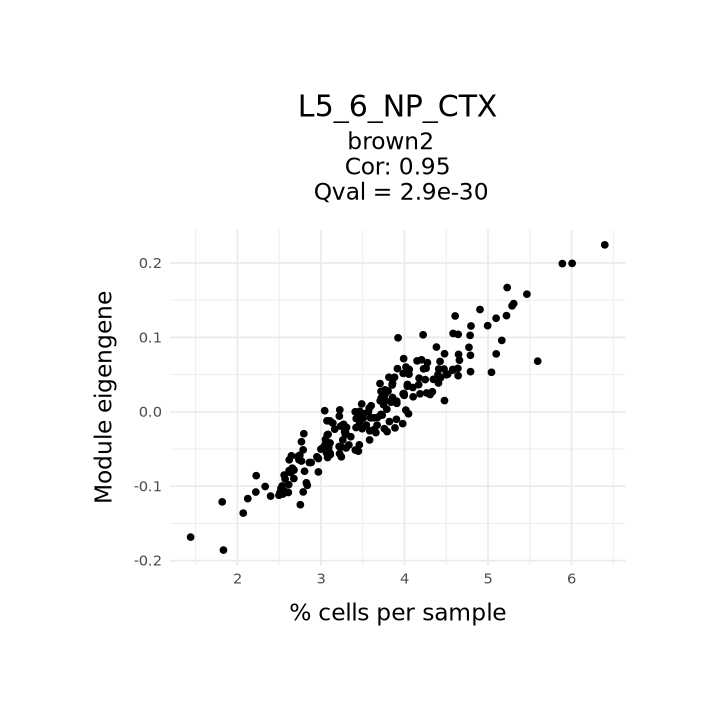

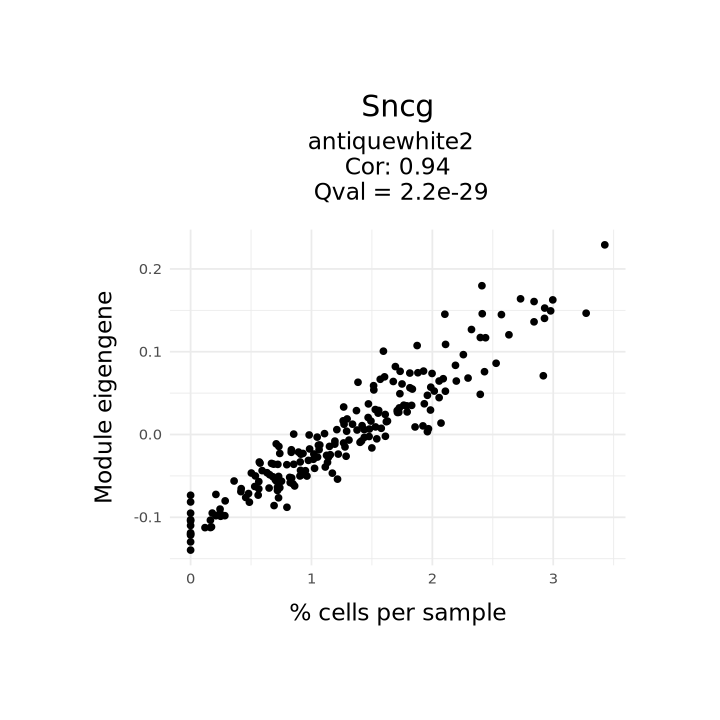

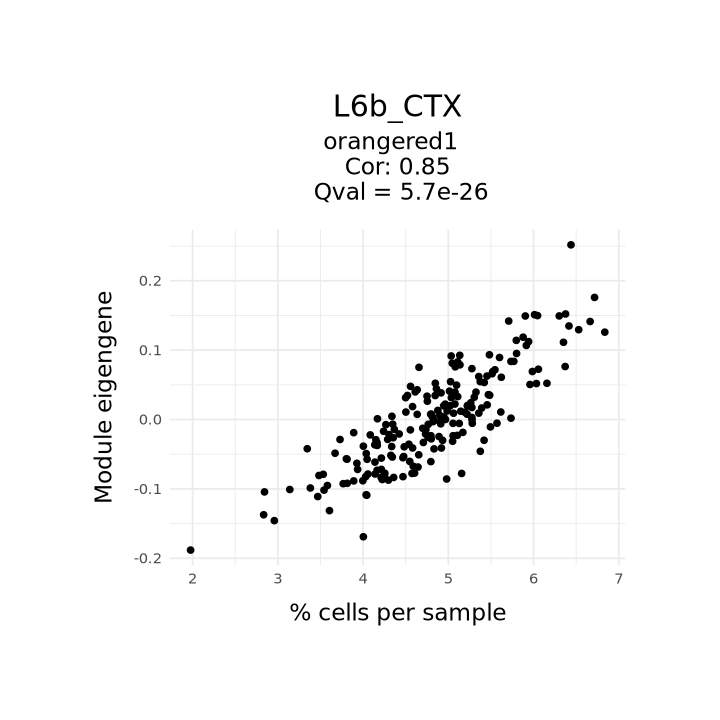

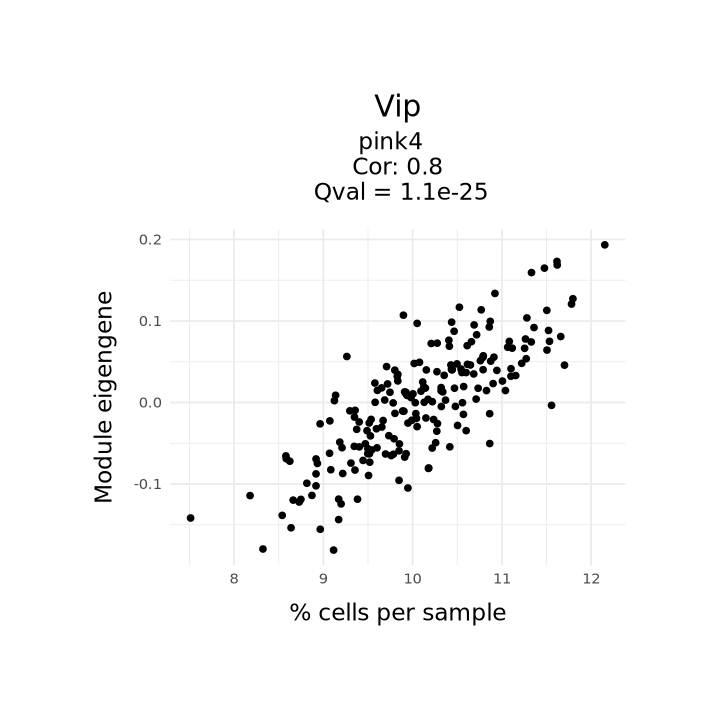

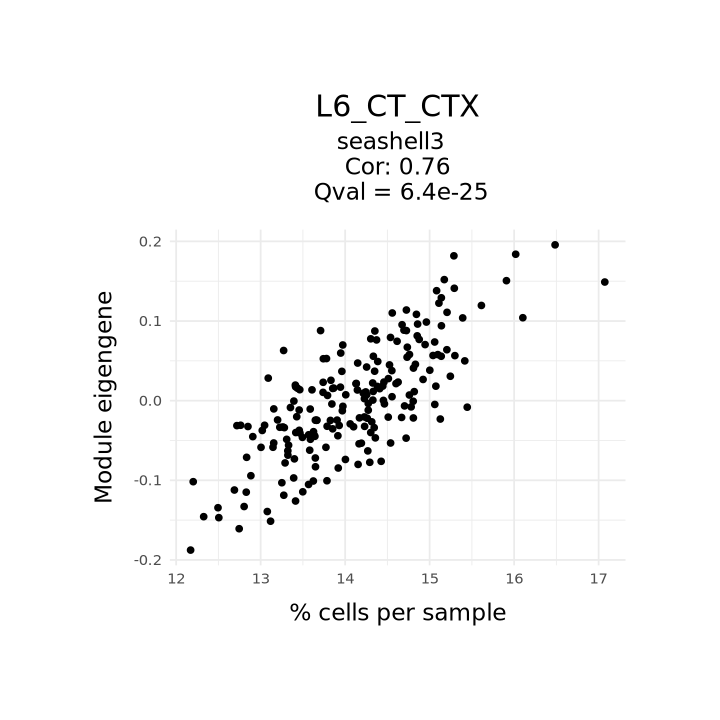

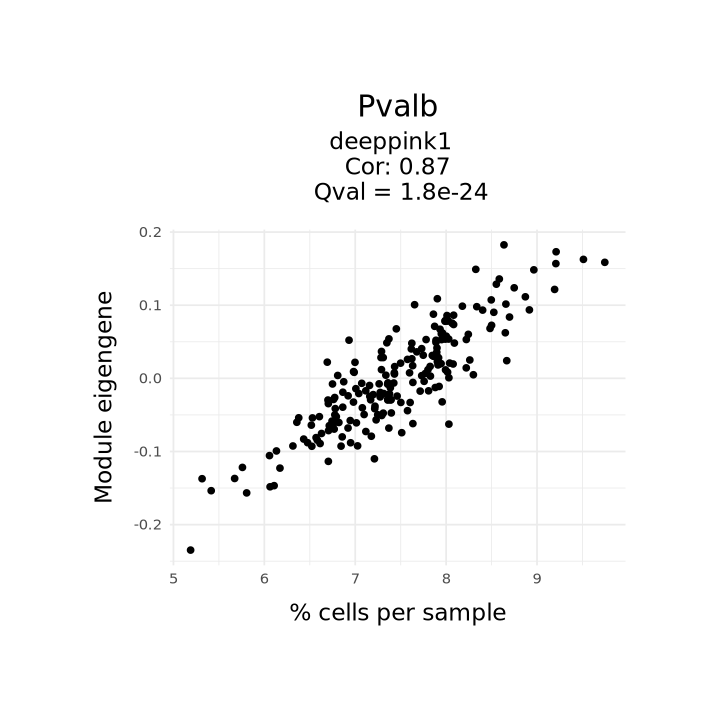

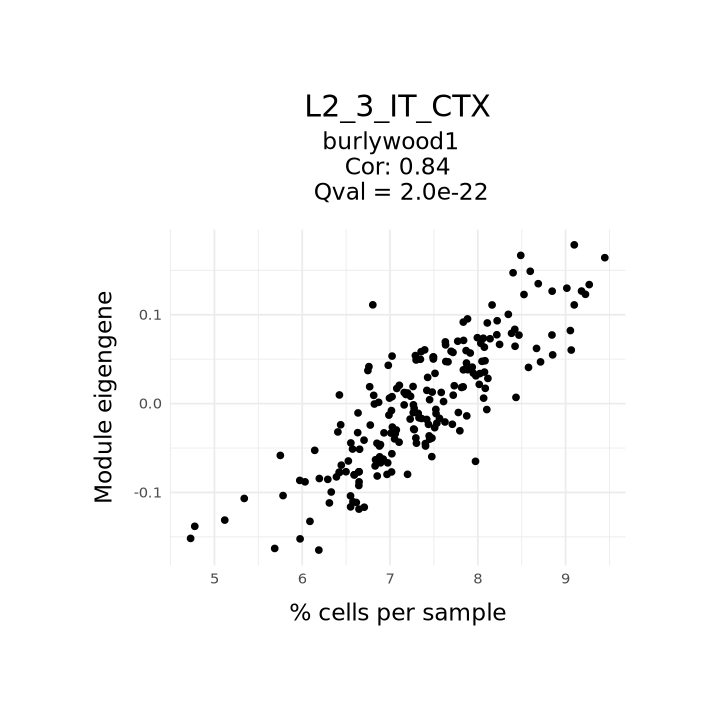

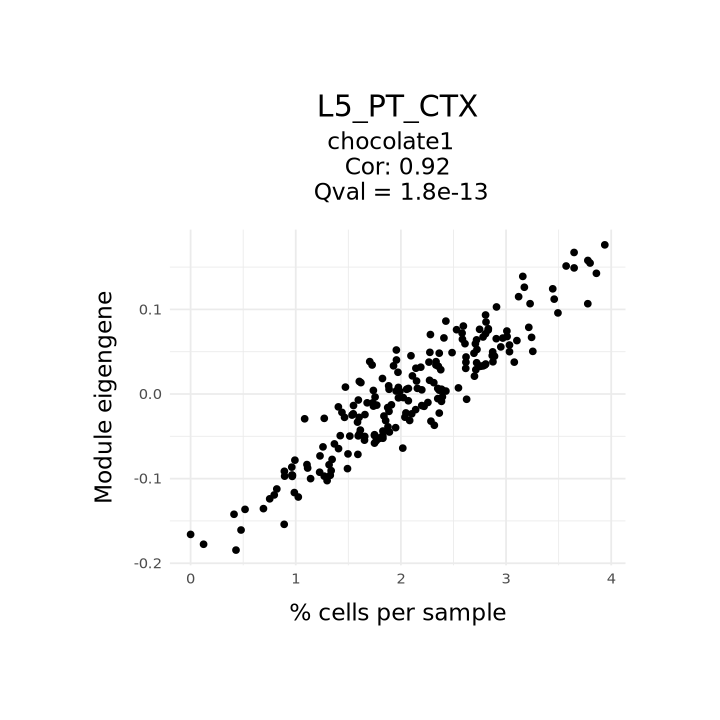

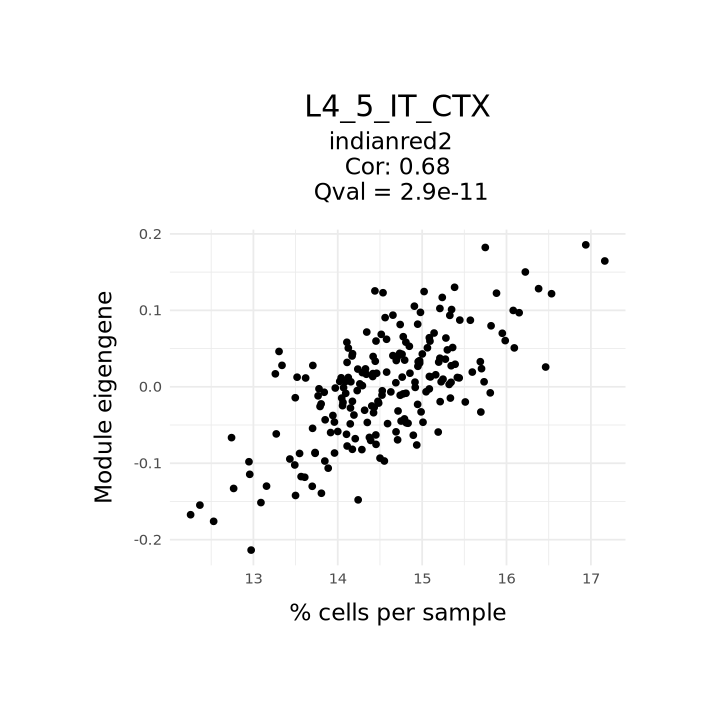

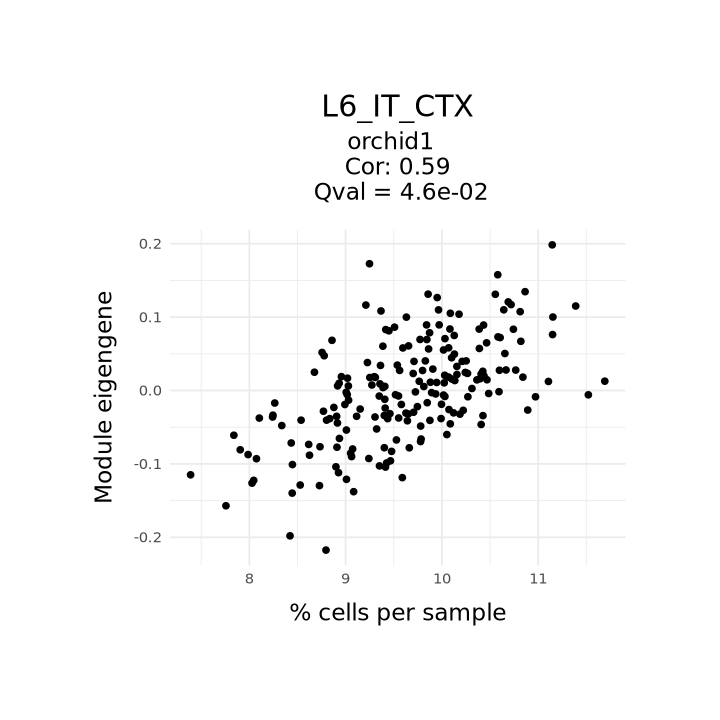

In [ ]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)